# Burger

In [1]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout
from sklearn.model_selection import train_test_split
from sklearn.utils import extmath
from module_utils import * 
sys.path.append('../utils')
from Structure import *
#######################     CONFIGURATIONS     ##########################
seed = 29
train = True
save = True


Ray module not found. Multiprocessing features are not available


# introduction of the data

In [2]:
# Functions

# High-fidelity model: exact analytical solution
def u_HF(x, t, re):
  A0 = np.exp(re/8.0)
  return x/(t+1)/(1.0+np.exp(re*(x**2)/(4*t+4))*((t+1)/A0)**0.5)

# Low-fidelity model
def u_LF(x, t, re):
  A0 = np.exp(re/8.0)
  return x/(t+1)/(1.0+np.exp(re*(x)/(4*t+4))*((t+1)/A0)**0.5)

In [3]:
# DATA

# Space-time discretization
nh, nt = 101, 151
T = 2.
L = 1.
x = np.linspace(0, L, nh) # spatial grid
t = np.linspace(0, T, nt) # timepoints

# Uniform sampling of 20 different reynolds numbers
nre = 20
re_min, re_max = 80, 500
re = np.linspace(0, 1, nre) # we sample in [0,1] in order to work with normalized data


In [4]:
#split in train/test with 20% data for testing
re_train, re_test = train_test_split(re, test_size=0.2, random_state=seed)
nre_train, nre_test = len(re_train), len(re_test)

# normalize = lambda r: (r-re_min)/(re_max-re_min) # maps [80, 500] onto [0, 1]
# denormalize = lambda r: r*(re_max-re_min) + re_min # maps [0, 1] onto [80, 500]

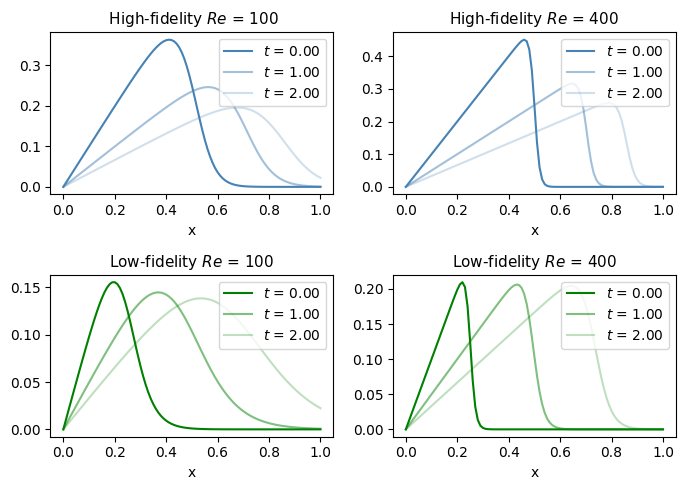

In [5]:
# Let's see some ground truth simulations
times = [0, nt//2, nt-1]
alphas = [1, 0.5, 0.25] # shades
plt.figure(figsize = (7, 5))
for j in range(3):
  plt.subplot(2,2,1)
  plt.plot(x, u_HF(x, t[times[j]], re = 100), label = "$t$ = %.2f" % t[times[j]], alpha = alphas[j], color = 'steelblue')
  plt.title(" High-fidelity $Re$ = 100", fontsize = 11)
  plt.xlabel('x')
  plt.legend(loc = 'upper right')
  plt.subplot(2,2,2)
  plt.plot(x, u_HF(x, t[times[j]], re = 400), label = "$t$ = %.2f" % t[times[j]], alpha = alphas[j], color = 'steelblue')
  plt.title("High-fidelity $Re$ = 400", fontsize = 11)
  plt.xlabel('x')
  plt.legend(loc = 'upper right')
  plt.subplot(2,2,3)
  plt.plot(x, u_LF(x, t[times[j]], re = 100), label = "$t$ = %.2f" % t[times[j]], alpha = alphas[j], color = 'green')
  plt.title("Low-fidelity $Re$ = 100", fontsize = 11)
  plt.xlabel('x')
  plt.legend(loc = 'upper right')
  plt.subplot(2,2,4)
  plt.plot(x, u_LF(x, t[times[j]], re = 400), label = "$t$ = %.2f" % t[times[j]], alpha = alphas[j], color = 'green')
  plt.title("Low-fidelity $Re$ = 400", fontsize = 11)
  plt.xlabel('x')
  plt.legend(loc = 'upper right')
plt.tight_layout()

#### (1) Generation of multi-fidelity dataset

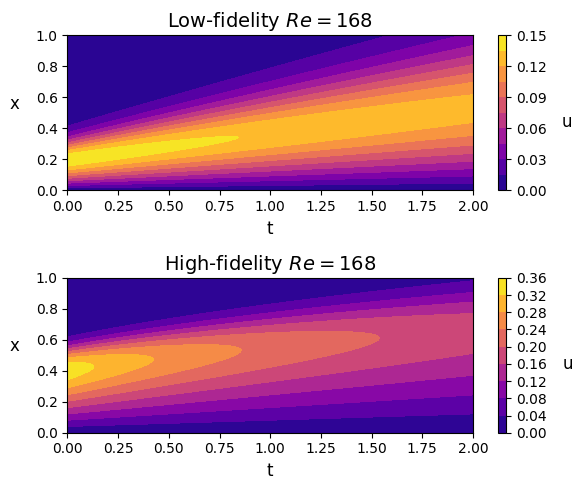

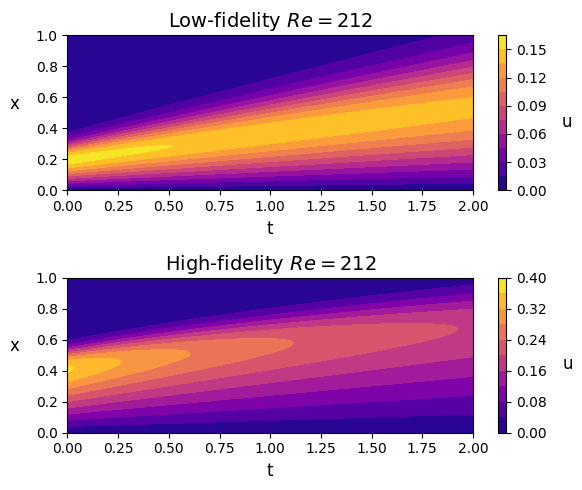

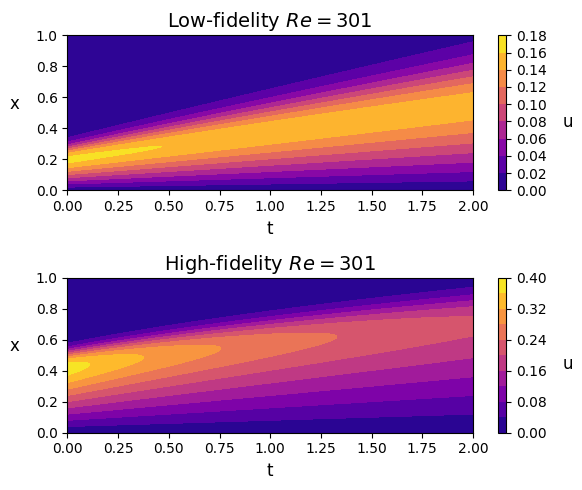

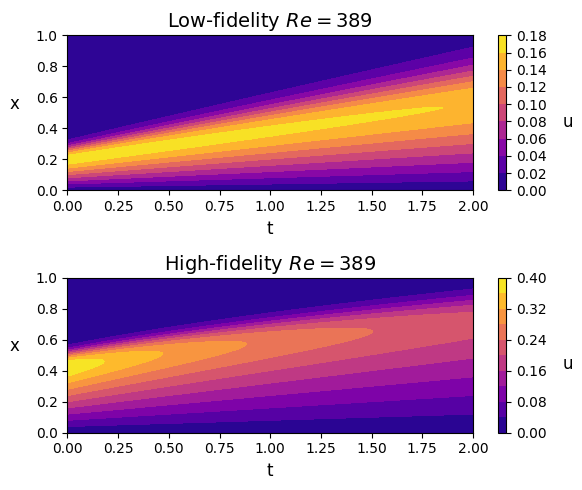

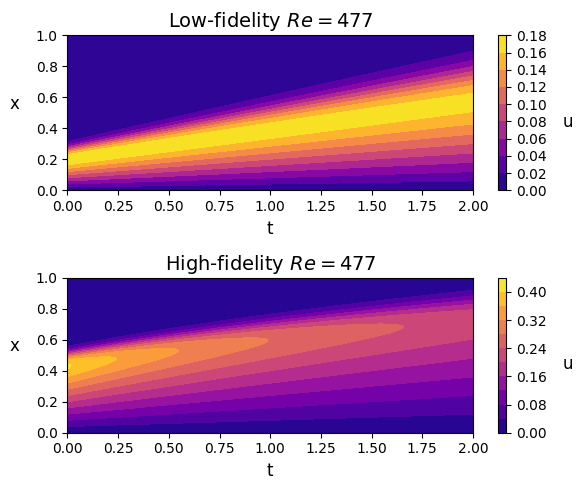

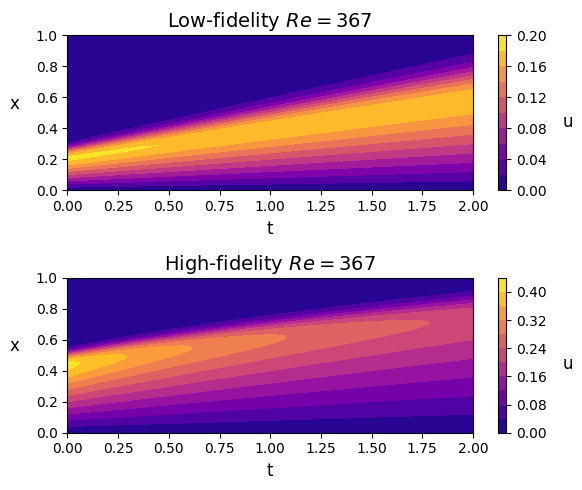

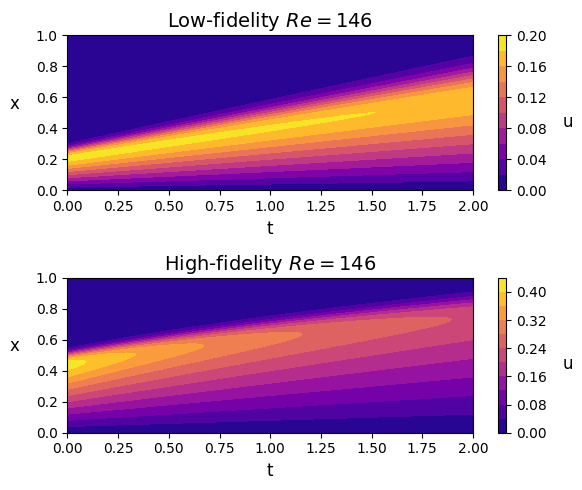

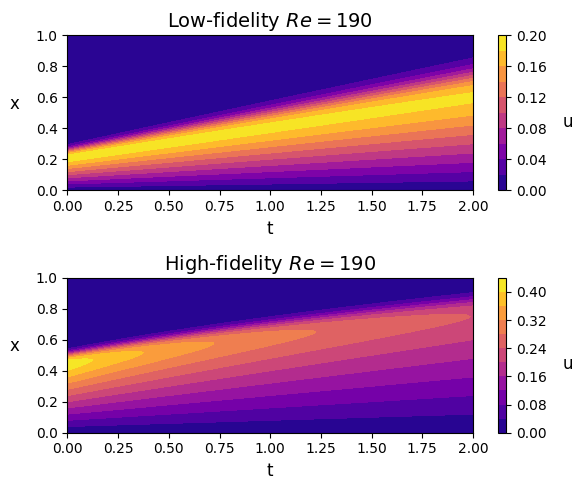

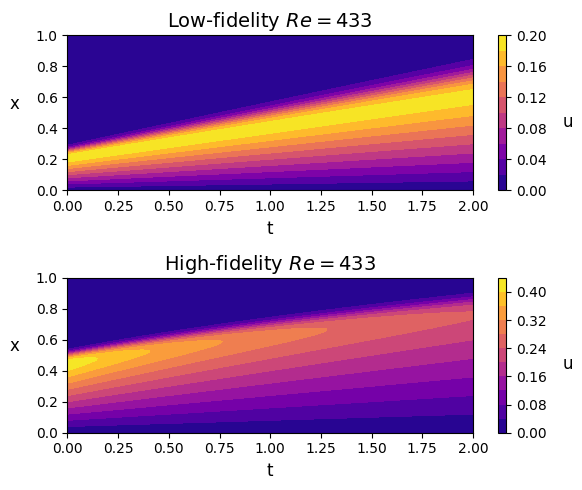

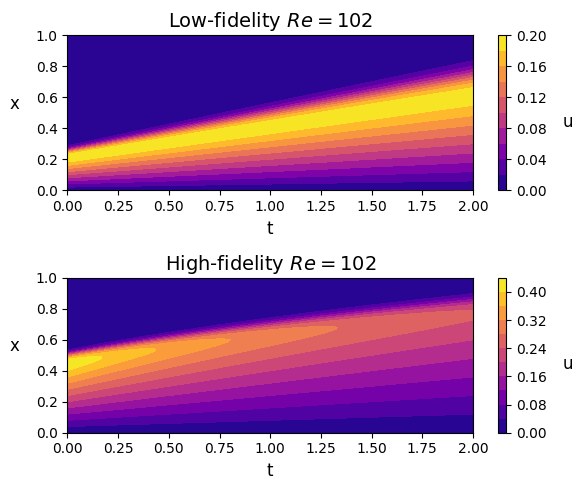

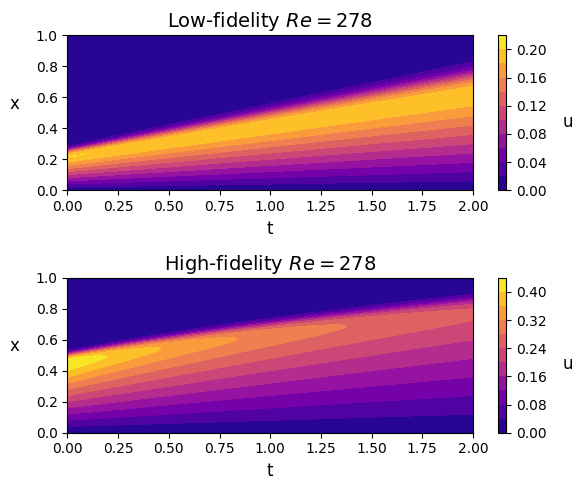

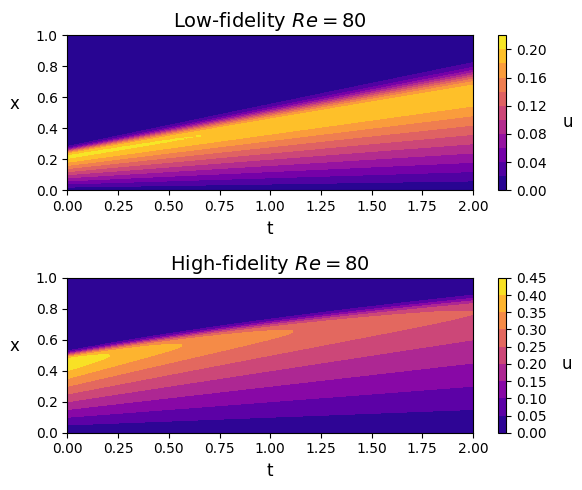

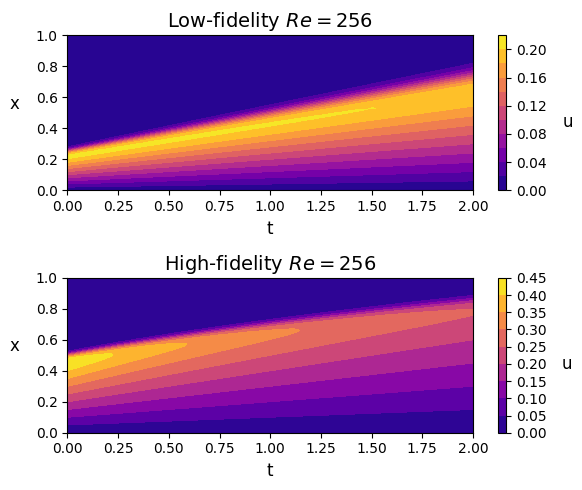

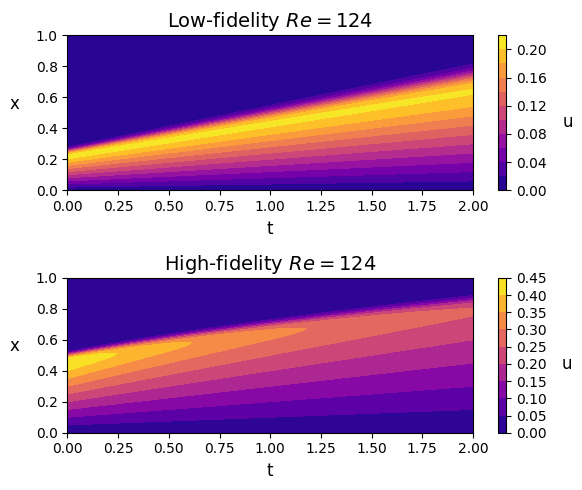

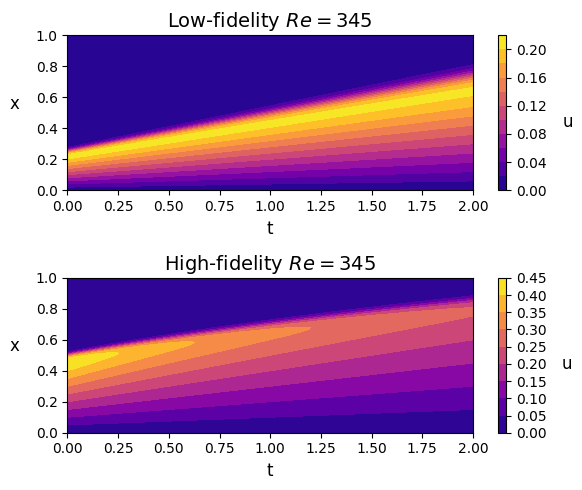

In [6]:
#Generate training data
u_hf = np.zeros((nre, nt, nh))
u_lf = np.zeros((nre, nt, nh))

for p in range(nre_train):
    for n in range(nt):
        for i in range(nh):
            u_hf[p, n, i] = u_HF(x[i], t[n], denormalization(re[p],re_max,re_min))
            u_lf[p, n, i] = u_LF(x[i], t[n], denormalization(re[p],re_max,re_min))


#Generate test data
u_hf_test = np.zeros((nre_test, nt, nh))
u_lf_test = np.zeros((nre_test, nt, nh))

for p in range(nre_test):
    for n in range(nt):
        for i in range(nh):
            u_hf_test[p, n, i] = u_HF(x[i], t[n], denormalization(re_test[p],re_max,re_min))
            u_lf_test[p, n, i] = u_LF(x[i], t[n], denormalization(re_test[p],re_max,re_min))

# Plot the data
# ind_re = 1 # Re = 367


for ind_re in range(15):
    t_grid, x_grid = np.meshgrid(t, x)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(211)
    surf = ax.contourf(t_grid, x_grid, u_lf[ind_re].T, cmap='plasma', levels=10)
    plt.xlabel('t', fontsize=12)
    plt.ylabel('x', fontsize=12, labelpad=15, rotation = 0)
    cbar = fig.colorbar(surf, ax=ax)
    cbar.ax.set_ylabel('u', fontsize=12, labelpad=15, rotation = 0)
    plt.title('Low-fidelity $Re = $' + str(int(denormalization(re_train[ind_re],re_max,re_min))), fontsize=14)
    ax = fig.add_subplot(212)
    surf = ax.contourf(t_grid, x_grid, u_hf[ind_re].T, cmap='plasma', levels=10)
    plt.xlabel('t', fontsize=12)
    plt.ylabel('x', fontsize=12, labelpad=15, rotation = 0)
    cbar = fig.colorbar(surf, ax=ax)
    cbar.ax.set_ylabel('u', fontsize=12, labelpad=15, rotation = 0)
    plt.title('High-fidelity $Re = $' + str(int(denormalization(re_train[ind_re],re_max,re_min))), fontsize=14)
    plt.tight_layout()
    plt.show()

#### (2) Dimensionality reduction via POD

In [7]:
def compute_randomized_SVD(S, N_POD, N_h, n_channels):
    U = np.zeros((n_channels * N_h, N_POD))
    for i in range(n_channels):
        U[i * N_h: (i + 1) * N_h], Sigma, Vh = extmath.randomized_svd(S[i * N_h: (i + 1) * N_h, :],
                                                                      n_components=N_POD, transpose=False,
                                                                      flip_sign=False, random_state=123)
    return U, Sigma


#########################   Proper Orthogonal Decomposition (POD)   ##########################
n_POD = 16 # we consider the first 16 basis functions

#Reshape for POD
u_hf_pod = np.reshape(u_hf, (nre*nt,nh))
#POD on HF training data
basis, S = compute_randomized_SVD(u_hf_pod, n_POD, nh, 1)

#### (3) Computing reduced-coordinates via projection

In [8]:
#########################   PROJECTION ONTO POD BASIS    ##########################
u_lf_pod = np.reshape(u_lf, (nre*nt,nh))
u_lf_pod_test = np.reshape(u_lf_test, (nre_test*nt,nh))
u_hf_pod_test = np.reshape(u_hf_test, (nre_test*nt,nh))

ulf_train = u_lf_pod @ basis      # ATTENTION same basis as u_hf_pod of before 
uhf_train = u_hf_pod @ basis
ulf_test = u_lf_pod_test @ basis
uhf_test = u_hf_pod_test @ basis

#Reshape to make data suitable to LSTM network
ulf_train = np.reshape(ulf_train, (nre, nt, n_POD))
uhf_train = np.reshape(uhf_train, (nre, nt, n_POD))
ulf_test = np.reshape(ulf_test, (nre_test, nt, n_POD))
uhf_test = np.reshape(uhf_test, (nre_test, nt, n_POD))

projection

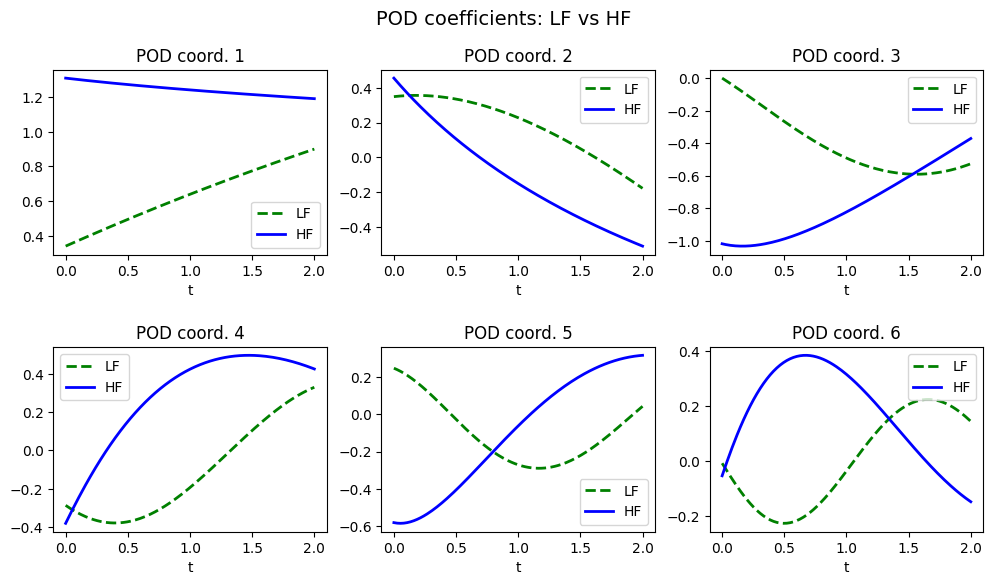

In [9]:
#Plot POD coefficients: LF vs HF
fig = plt.figure(figsize=(12,6))
plt.subplots_adjust(hspace=0.5)
fig.suptitle('POD coefficients: LF vs HF', fontsize=14)
for mode in range(6):
    ax = fig.add_subplot(231 + mode)
    plt.plot(t, ulf_train[ind_re,:,mode], label = 'LF', linewidth = 2, color = 'green', linestyle = '--')
    plt.plot(t, uhf_train[ind_re, :, mode], label = 'HF', linewidth = 2, color = 'blue')
    ax.title.set_text('POD coord. ' + str(mode+1))
    plt.xlabel('t')
    plt.legend()
plt.show()

#### (4) Training LSTM neural network surrogate model


Epoch 1/500


45/45 [==============================] - 2s 4ms/step - loss: 0.0569 - mse: 0.0569
Epoch 2/500
45/45 [==============================] - 0s 4ms/step - loss: 0.0255 - mse: 0.0255
Epoch 3/500
45/45 [==============================] - 0s 5ms/step - loss: 0.0178 - mse: 0.0178
Epoch 4/500
45/45 [==============================] - 0s 5ms/step - loss: 0.0137 - mse: 0.0137
Epoch 5/500
45/45 [==============================] - 0s 5ms/step - loss: 0.0114 - mse: 0.0114
Epoch 6/500
45/45 [==============================] - 0s 5ms/step - loss: 0.0098 - mse: 0.0098
Epoch 7/500
45/45 [==============================] - 0s 4ms/step - loss: 0.0085 - mse: 0.0085
Epoch 8/500
45/45 [==============================] - 0s 4ms/step - loss: 0.0076 - mse: 0.0076
Epoch 9/500
45/45 [==============================] - 0s 6ms/step - loss: 0.0068 - mse: 0.0068
Epoch 10/500
45/45 [==============================] - 0s 6ms/step - loss: 0.0062 - mse: 0.0062
Epoch 11/500
45/45 [==============================] - 0s

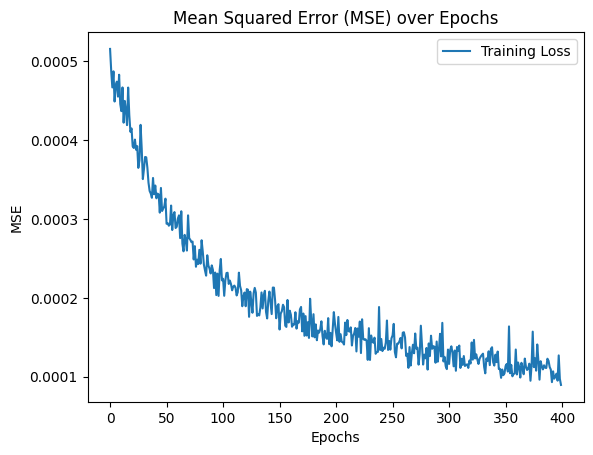

In [10]:
# Reshape to make data suitable to LSTM network

# Train
# dai come ingresso u_lf proiettato su basi 
t_grid_lstm, re_grid_lstm = np.meshgrid(t, re)
input_train = np.concatenate((t_grid_lstm[:,:,np.newaxis], re_grid_lstm[:,:,np.newaxis], ulf_train), axis = 2)
output_train = uhf_train

#Test
t_grid_lstm_test, re_grid_lstm_test = np.meshgrid(t, re_test)
input_test = np.concatenate((t_grid_lstm_test[:,:,np.newaxis], re_grid_lstm_test[:,:,np.newaxis], ulf_test), axis = 2)
output_test = uhf_test

#########################   LSTM NN HYPERPARAMETERS    ##########################
params_NN = { 'lay': 1,
             'nodes': 64,
             'lr':  1e-3,
             'opt': 'Adamax',
             'sequence_freq': 2,
             'sequence_length': 10,
             'epochs':  500,
             'patience' : 50,
             'dropout' : 0.1}

model=NetworkFactory.build_network("LSTM", params=params_NN, data_train=input_train, output_train=output_train, N=params_NN["epochs"],train=True,do_HPO=False,verbose=False)
# ############################   TRAINING/LOADING    ##############################

# if train:
#     #Split the data into subsequences
#     sequence_length = int(params_NN['sequence_length'])
#     sequence_freq = int(params_NN['sequence_freq'])
#     input_train_seq, output_train_seq = sliding_windows(input_train, output_train, sequence_length, sequence_freq)

#     #Create the LSTM NN model
#     model = create_model(params_NN, dim_input = n_POD + 2, dim_output = n_POD) #dim_input = param + time + POD modes ==  1 + 1 + n_POD

#     #Train the model
#     callback = tf.keras.callbacks.EarlyStopping(monitor='mse', patience=params_NN['patience'], restore_best_weights=True)
#     tf.keras.utils.set_random_seed(seed)
#     tf.config.experimental.enable_op_determinism() # for reproducibility
#     hist = model.fit(input_train_seq, output_train_seq, epochs=params_NN['epochs'], verbose = 1, callbacks=[callback])

# else:
#     name = './models/MF_POD_model'
#     model = tf.keras.models.load_model(name)
# if save:
#     name = './models/MF_POD_model_new'
#     model.save(name)

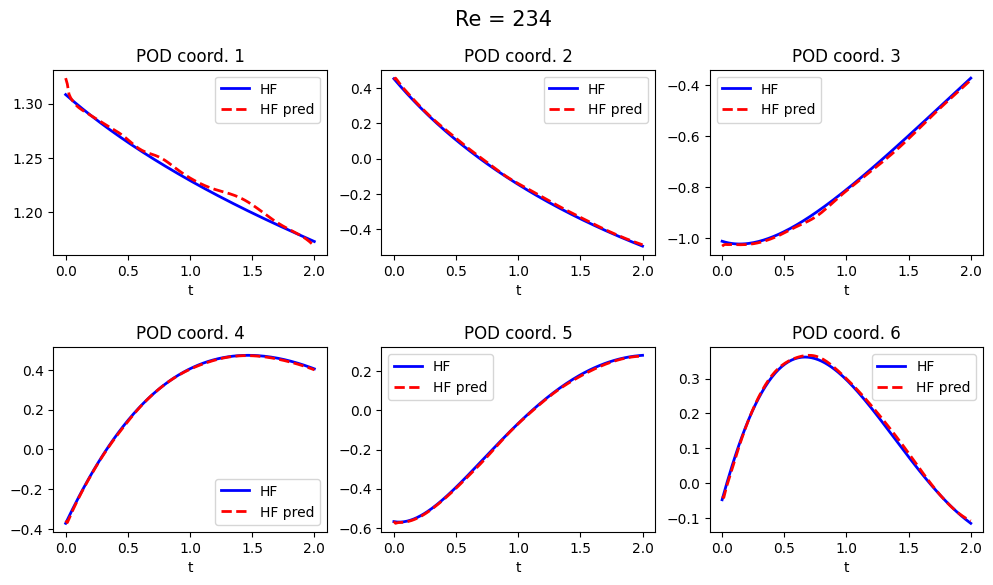

In [11]:
#########################   PREDICTION    ##########################

# Predictions on test data
output_pred = model.prediction(input_test)

# Plot predicted POD coordinates
ind_test = [0] # Re = 235
for ind_re in ind_test:
    fig = plt.figure(figsize=(12,6))
    plt.subplots_adjust(hspace=0.5)
    fig.suptitle('Re = ' + str(int(denormalization(re_test[ind_re],re_max,re_min))), fontsize=15)
    for mode in range(6):
      plt.subplot(231 + mode)
      plt.plot(t, output_test[ind_re,:,mode],'b-', label = 'HF', linewidth = 2)
      plt.plot(t, output_pred[ind_re, :, mode], 'r--', label = 'HF pred', linewidth = 2)
      plt.xlabel('t')
      plt.title('POD coord. ' + str(mode+1))
      plt.legend()
    plt.show()
     

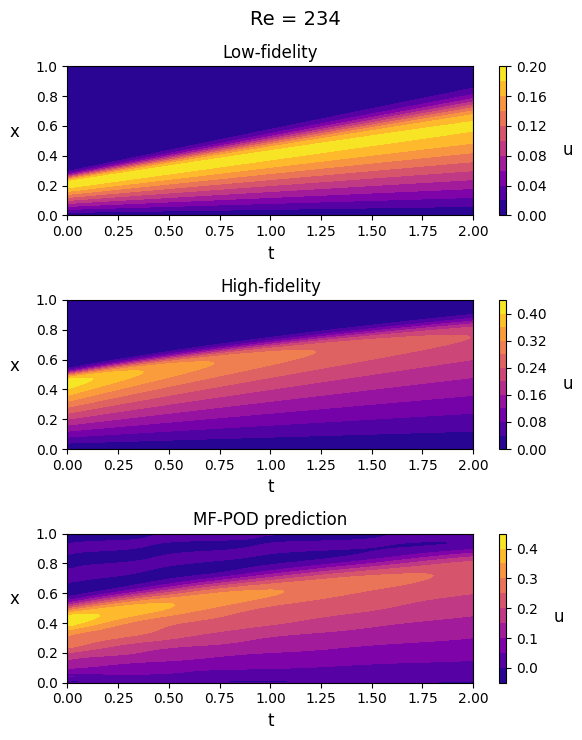

In [12]:
#Reconstruct solution

u_pred = output_pred @ basis.T

#Compare with HF solution
for ind_re in ind_test:
  fig = plt.figure(figsize=(6, 7.5))
  plt.suptitle('Re = ' + str(int(denormalization(re_test[ind_re],re_max,re_min))), fontsize = 14)
  ax = fig.add_subplot(311)
  surf = ax.contourf(t_grid, x_grid, u_lf_test[ind_re].T, cmap='plasma', levels=10)
  plt.xlabel('t', fontsize=12)
  plt.ylabel('x', fontsize=12, labelpad=15, rotation = 0)
  cbar = fig.colorbar(surf, ax=ax)
  cbar.ax.set_ylabel('u', fontsize=12, labelpad=15, rotation = 0)
  plt.title('Low-fidelity', fontsize=12)
  ax = fig.add_subplot(312)
  surf = ax.contourf(t_grid, x_grid, u_hf_test[ind_re].T, cmap='plasma', levels=10)
  plt.xlabel('t', fontsize=12)
  plt.ylabel('x', fontsize=12, labelpad=15, rotation = 0)
  cbar = fig.colorbar(surf, ax=ax)
  cbar.ax.set_ylabel('u', fontsize=12, labelpad=15, rotation = 0)
  plt.title('High-fidelity', fontsize=12)
  ax = fig.add_subplot(313)
  surf = ax.contourf(t_grid, x_grid, u_pred[ind_re].T, cmap='plasma', levels=10)
  plt.xlabel('t', fontsize=12)
  plt.ylabel('x', fontsize=12, labelpad=15, rotation = 0)
  cbar = fig.colorbar(surf, ax=ax)
  cbar.ax.set_ylabel('u', fontsize=12, labelpad=15, rotation = 0)
  plt.title('MF-POD prediction', fontsize=12)
  plt.tight_layout()
  plt.show()

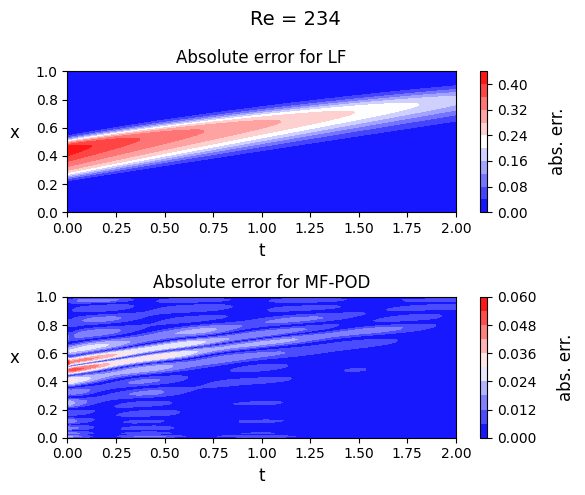

In [13]:
#Compute and plot errors
rel_err_lf = np.linalg.norm(u_lf_test - u_hf_test)/np.linalg.norm(u_hf_test[ind_re])
rel_err_pred = np.linalg.norm(u_pred - u_hf_test)/np.linalg.norm(u_hf_test[ind_re])

abs_err_lf = np.abs(u_lf_test - u_hf_test)
abs_err_pred = np.abs(u_pred - u_hf_test)

for ind_re in ind_test:
  fig = plt.figure(figsize=(6, 5))
  plt.suptitle('Re = ' + str(int(denormalization(re_test[ind_re],re_max,re_min))), fontsize = 14)
  ax = fig.add_subplot(211)
  surf = ax.contourf(t_grid, x_grid, abs_err_lf[ind_re].T, cmap='bwr', levels=10)
  cbar = fig.colorbar(surf, ax=ax)
  cbar.ax.set_ylabel('abs. err.', fontsize=12, labelpad=15)
  plt.xlabel('t', fontsize=12)
  plt.ylabel('x', fontsize=12, labelpad=15, rotation = 0)
  plt.title('Absolute error for LF', fontsize=12)
  ax = fig.add_subplot(212)
  surf = ax.contourf(t_grid, x_grid, abs_err_pred[ind_re].T, cmap='bwr', levels=10)
  cbar = fig.colorbar(surf, ax=ax)
  cbar.ax.set_ylabel('abs. err.', fontsize=12, labelpad=15)
  plt.xlabel('t', fontsize=12)
  plt.ylabel('x', fontsize=12, labelpad=15, rotation = 0)
  plt.title('Absolute error for MF-POD', fontsize=12)
  plt.tight_layout()
  plt.show()

Noise: 0.05
Number of data: 110
sigma: 1.0
step random walk: 0.1
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/3


Running chain, α = 0.21: 100%|██████████| 3000/3000 [14:29<00:00,  3.45it/s]


Sampling chain 2/3


Running chain, α = 0.25: 100%|██████████| 3000/3000 [14:40<00:00,  3.41it/s]


Sampling chain 3/3


Running chain, α = 0.21: 100%|██████████| 3000/3000 [14:42<00:00,  3.40it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.196]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.196  0.06   0.074    0.272      0.003    0.002     370.0     214.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.17242105]



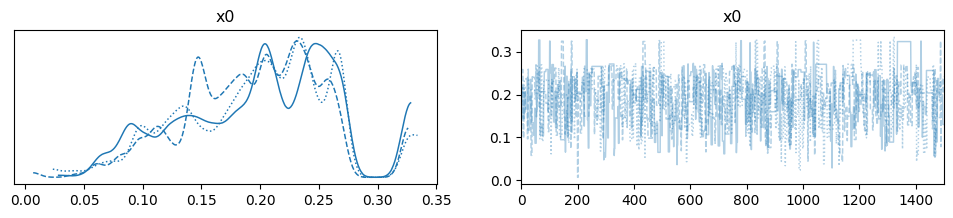

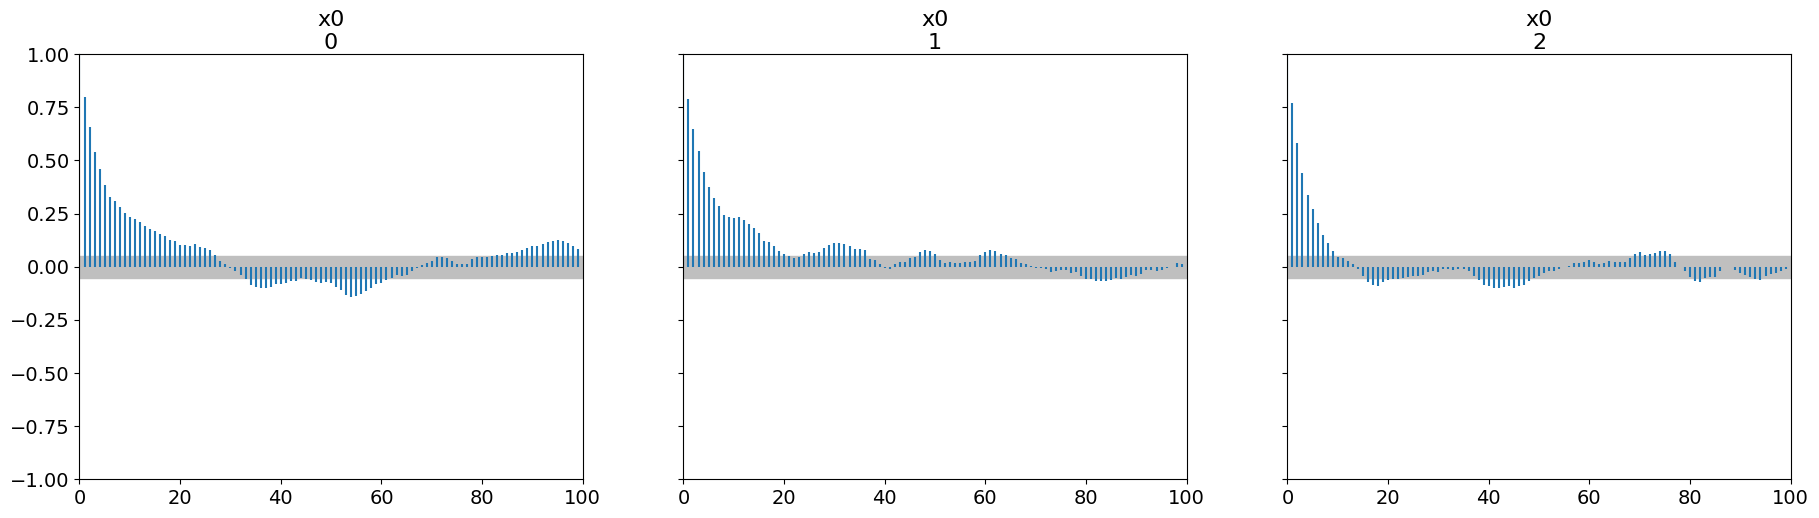

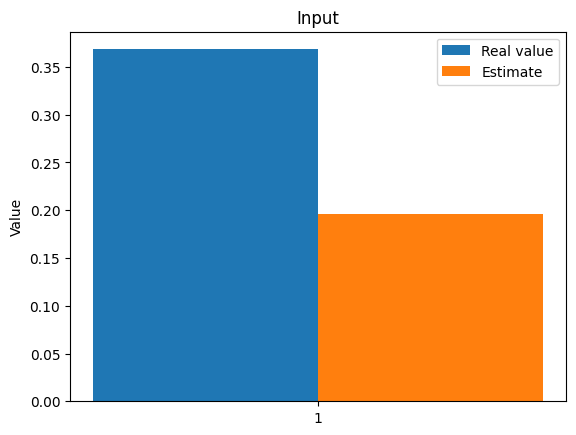

The function param_inverse took 2634.8561754226685 seconds.
step random walk: 0.2
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/3


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13904\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.23: 100%|██████████| 3000/3000 [14:45<00:00,  3.39it/s]


Sampling chain 2/3


Running chain, α = 0.15: 100%|██████████| 3000/3000 [14:43<00:00,  3.40it/s]


Sampling chain 3/3


Running chain, α = 0.18: 100%|██████████| 3000/3000 [14:53<00:00,  3.36it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.195]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.195  0.062   0.059    0.273      0.002    0.002     616.0     462.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.17342105]



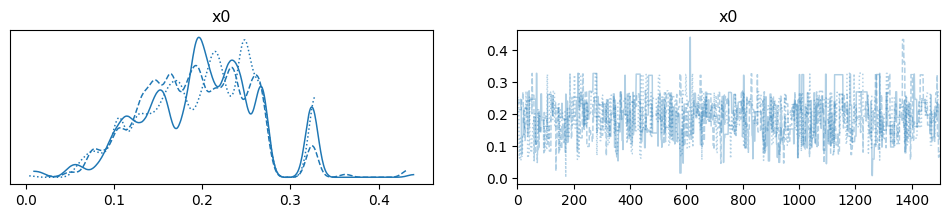

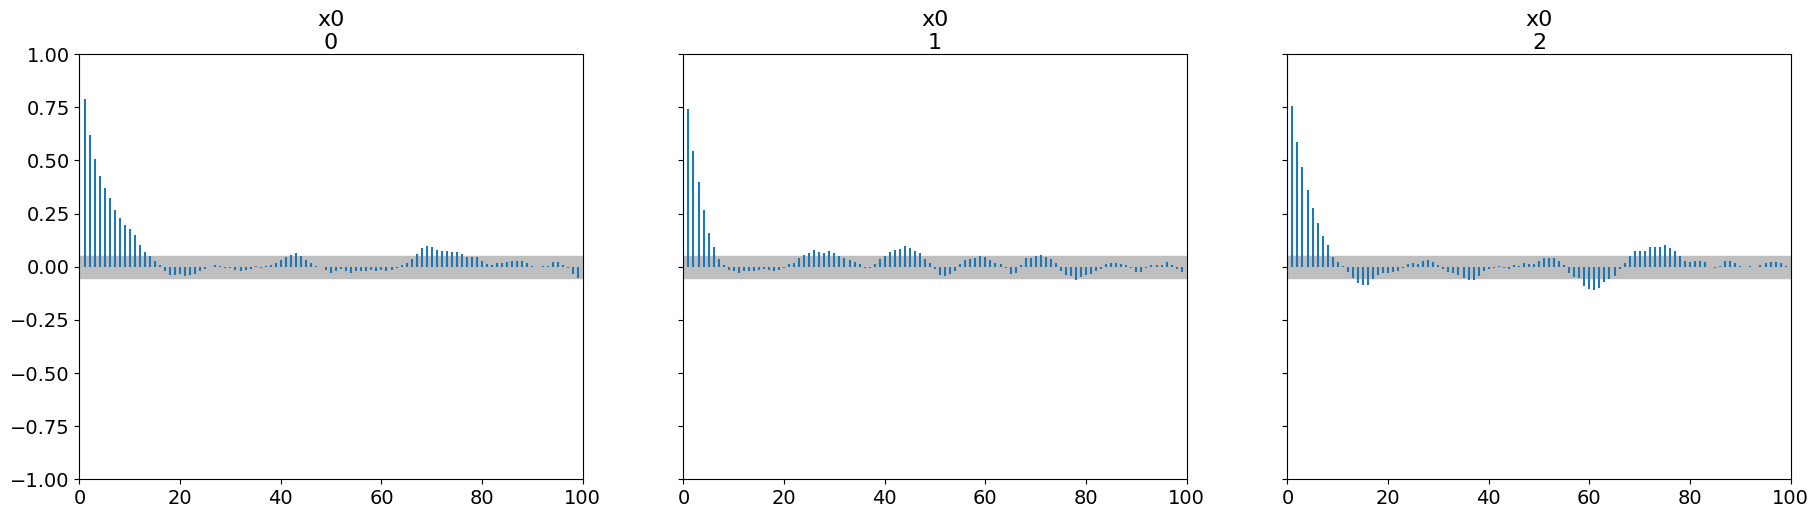

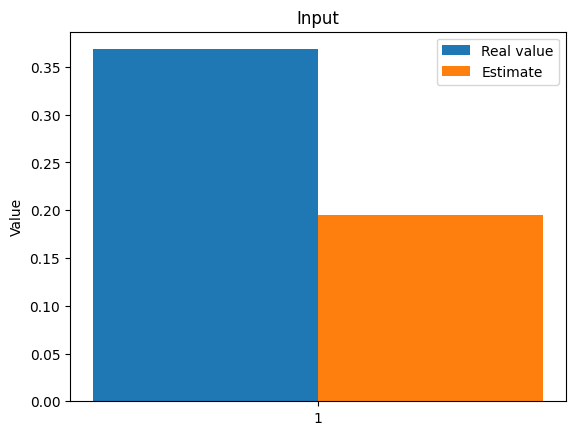

The function param_inverse took 2664.108906507492 seconds.
step random walk: 0.05
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/3


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13904\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.23: 100%|██████████| 3000/3000 [15:54<00:00,  3.14it/s]


Sampling chain 2/3


Running chain, α = 0.40: 100%|██████████| 3000/3000 [14:56<00:00,  3.35it/s]


Sampling chain 3/3


Running chain, α = 0.11: 100%|██████████| 3000/3000 [14:57<00:00,  3.34it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.175]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.175  0.888   -1.04    1.051      0.504    0.396       4.0      19.0   

    r_hat  
x0   2.09  
Autocorrelation...
the difference between estimated values [0.19342105]



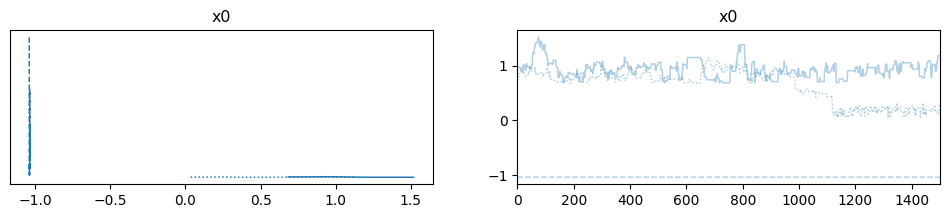

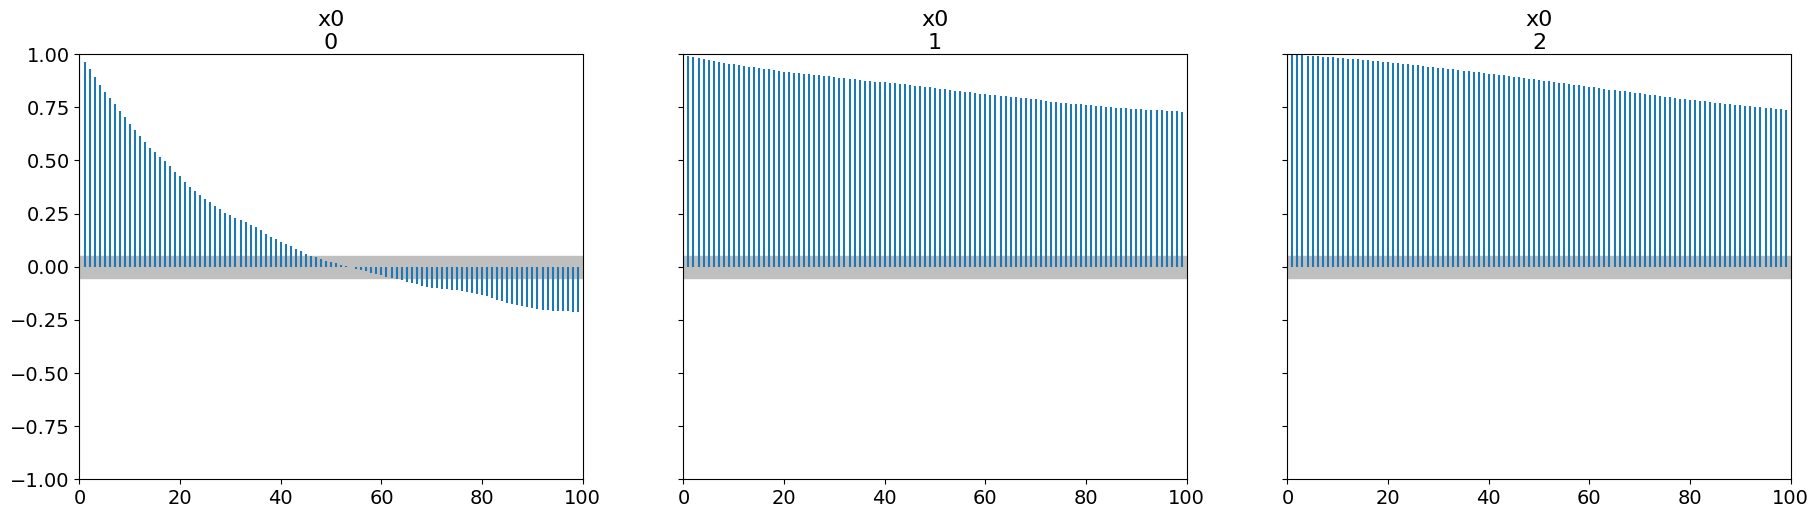

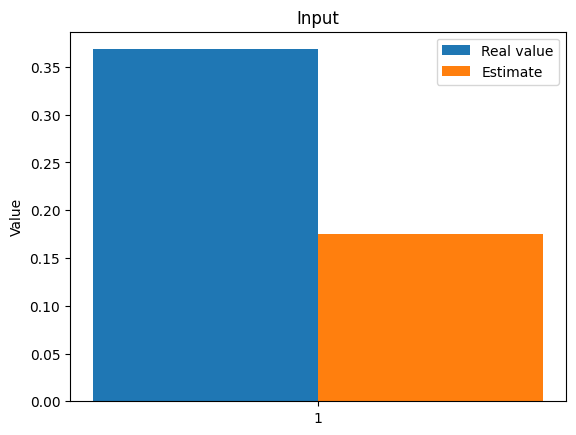

The function param_inverse took 2749.7209055423737 seconds.
sigma: 2.0
step random walk: 0.1
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/3


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13904\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.19: 100%|██████████| 3000/3000 [14:40<00:00,  3.41it/s]


Sampling chain 2/3


Running chain, α = 0.21: 100%|██████████| 3000/3000 [15:15<00:00,  3.28it/s]


Sampling chain 3/3


Running chain, α = 0.25: 100%|██████████| 3000/3000 [15:17<00:00,  3.27it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.408]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.408  0.433  -0.049    1.328      0.024    0.017     339.0     660.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.03957895]



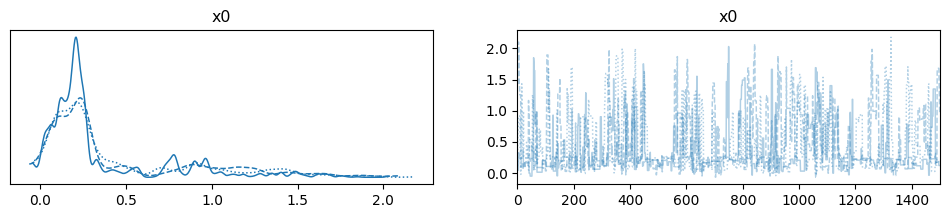

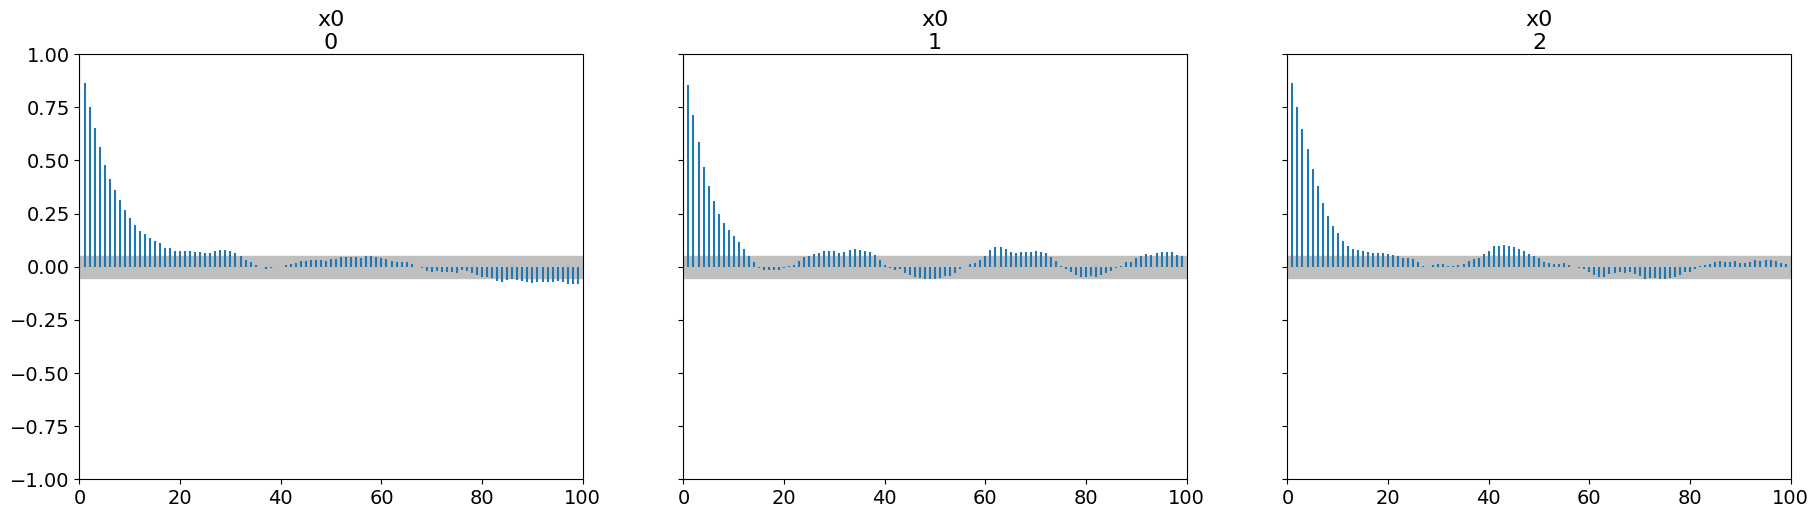

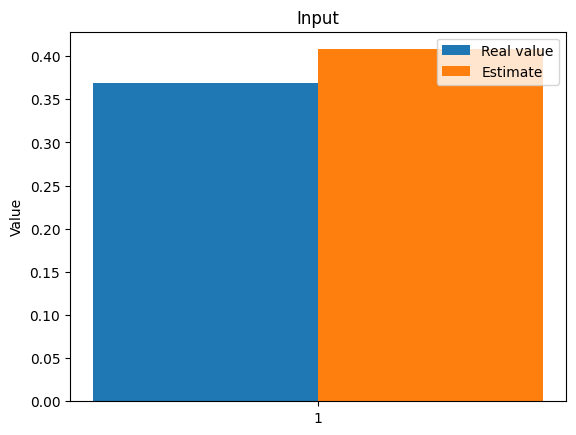

The function param_inverse took 2714.9893550872803 seconds.
step random walk: 0.2
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/3


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13904\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.37:  24%|██▍       | 726/3000 [03:47<11:51,  3.20it/s]


KeyboardInterrupt: 

In [ ]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[110]
parameter=np.array([re_grid_lstm_test[0,0]])
#indices = np.where(input_test[:,:,1] == parameter)[0]
mean_prior=np.array([.5])
cov_prior=np.diag([1])
# cov_linkelihood
sigma=np.array([1,2,4.])   # NB, con sigma piccolo (e.g. 1) funzia, sigma troppo gaìrande no

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.1,0.2,0.05])
rwmh_adaptive = True
iterations =3000
burnin = 1500
n_chains=3

algo="MH"


estimateMF, errorMF= run_simulation(basis,input_test, T,mean_prior, cov_prior, output_test, sigma_noise, n_data, parameter, sigma, rmwh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, model,algo)
# FUnziona, obiettivo ora, ridurre varianza della posterior

## Inversion

In [14]:

# potrebbero andare in utils
def process_data(datahf, parameters, t_eval, Yhf):
    # """
    # Find the elements of a dataset nearest to the ones given
    # """
    mask = datahf[:,:,1] == parameters
    datahf_values=datahf[mask]
    datahf_values=np.expand_dims(datahf_values, axis=0)

    t_eval_values = t_eval[:, 0]  # Simplify t_eval to a 1D array if not already
    t_eval_values = t_eval_values[np.newaxis, :]

    # Extract the first dimension slice (:, :, 0) from the original matrix
    slice_0 = datahf_values[0, :, 0]

    # Compute the absolute differences in a vectorized manner
    # The result will be of shape (151, 50)
    differences = np.abs(slice_0[:, np.newaxis] - t_eval_values[0, np.newaxis, :])

    # Find the indices of the minimum values along axis 0
    indices = np.argmin(differences, axis=0)

    # Use the indices to extract the rows from the original matrix
    new_matrix = datahf_values[:, indices, :]

    y_obs=Yhf[np.where(mask==True)[0][0],indices,:]

    return new_matrix, np.expand_dims(y_obs, axis=0)




    # indices = np.where(datahf[:,:,1] == parameters)
    # indices = np.column_stack((indices[0], indices[1]))
    
    # if len(indices)==0:
    #     raise ValueError(f" No observations related to parameter: {parameters}")
    
    # rows = indices[:, 0]
    # cols = indices[:, 1]

    # # Assuming you want to extract the elements from all "depth" levels of the 3D array
    # depth_indices = np.arange(datahf.shape[2])

    # # Use broadcasting to create the full index set



    # datahf_values = datahf[rows[:, np.newaxis], cols[:, np.newaxis], depth_indices]
    # datahf_values = datahf_values[:, np.newaxis]
    # t_eval_values = t_eval[:, 0]  # Simplify t_eval to a 1D array if not already
    # t_eval_values = t_eval_values[np.newaxis, :]
    # differences = np.abs(datahf_values[:,:,0] - t_eval_values)
    # closest_indices = np.argmin(differences, axis=0)

    # rows = indices[closest_indices, 0]
    # cols = indices[closest_indices, 1]


    # # nearest_x = datahf[rows,cols, 0]  # x values closest to each t_eval
    # # nearest_y = datahf[rows,cols, 2] #
    # # nearest_z = datahf[rows,cols, 3] #
    # # y_obs = Yhf[rows,cols,:]  # Corresponding y values from Yhf


    # nearest_x = datahf[rows, cols, 0].reshape(-1,1)  # x values closest to each t_eval
    # last_dims = datahf[rows, cols, 2:]  # Selec-1,1t the last 16 dimensions

    # # Stack the first dimension with the last 16 dimensions
    # stacked_datahf = np.concatenate((nearest_x, last_dims), axis=-1)
    # y_obs = Yhf[rows, cols, :]  # Corresponding y values from Yhf





    # return stacked_datahf, y_obs.reshape(1,y_obs.shape[0],y_obs.shape[1])



def run_simulation(basis,datahf, T, mean_prior, cov_prior, Yhf, sigma_noise, n_data, parameters, sigma, rmwh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo):
    
    error = np.zeros((len(sigma_noise), len(n_data), sigma.shape[0], rmwh_scaling.shape[0]))
    estimate_MF=np.zeros((len(sigma_noise), len(n_data), sigma.shape[0], rmwh_scaling.shape[0]))


    for i,noise in enumerate(sigma_noise):

        print(f"Noise: {noise}")

        for k,n in enumerate(n_data):
            print(f"Number of data: {n}")
            for t,s in enumerate(sigma):
                print(f"sigma: {s}")
                for j,r in enumerate(rmwh_scaling):

                    print(f"step random walk: {r}")       
                    
                    t_eval = np.linspace(0., T, n).reshape(-1,1)
                    
                    nearest_x, y_obs = process_data(datahf, parameters, t_eval, Yhf)
                    print(nearest_x.shape)
                    estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
                    
        smallest_index = np.unravel_index(np.argmin(error), error.shape)
        print(f"The best estimate is given by: sigma_noise={sigma_noise[smallest_index[0]]}, number of data= {n_data[smallest_index[1]]}, sigma={sigma[smallest_index[2]]}, rmwh_scaling={rmwh_scaling[smallest_index[3]]}")

    return estimate_MF[smallest_index],error


In [14]:
[re_grid_lstm_test[:,0]]

[array([0.36842105, 0.57894737, 0.78947368, 0.89473684])]

Noise: 0.05
Number of data: 151
sigma: 0.5
step random walk: 0.1
(1, 151, 18)
real values are [0.36842105]
Sampling chain 1/2


Running chain, α = 0.20: 100%|██████████| 2000/2000 [07:19<00:00,  4.55it/s]


Sampling chain 2/2


Running chain, α = 0.32: 100%|██████████| 2000/2000 [07:32<00:00,  4.42it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.476]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.476  0.134   0.238    0.727      0.007    0.005     315.0     402.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.10757895]



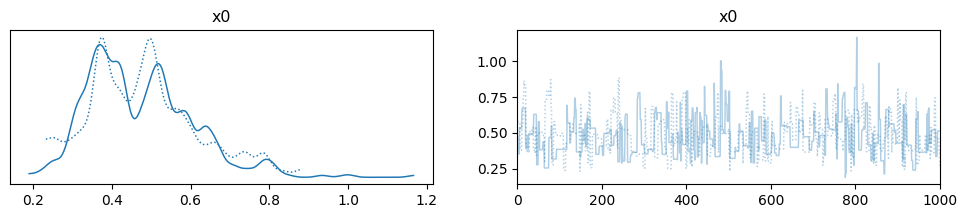

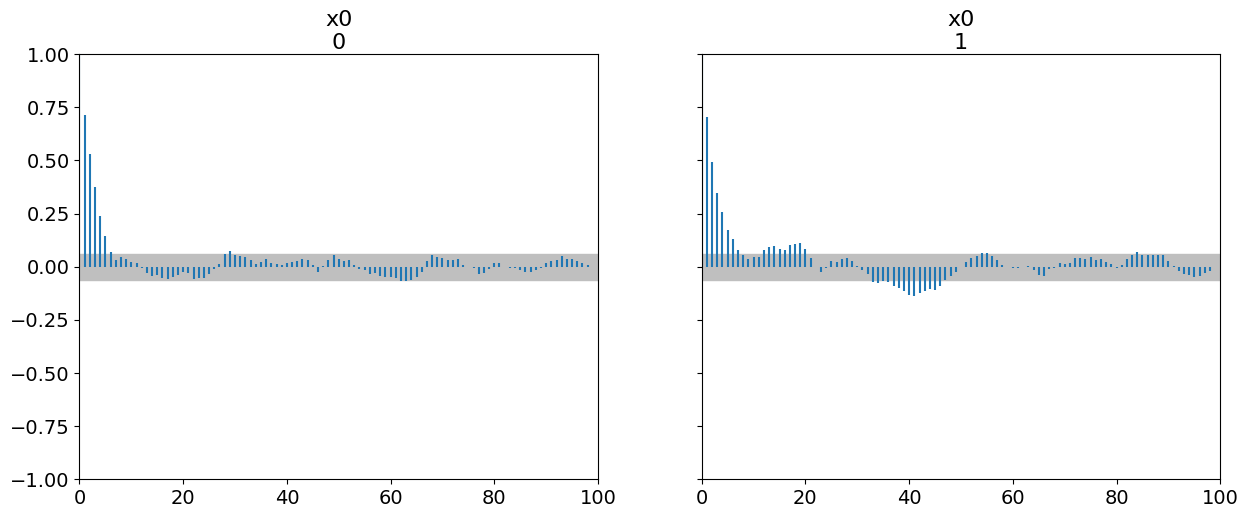

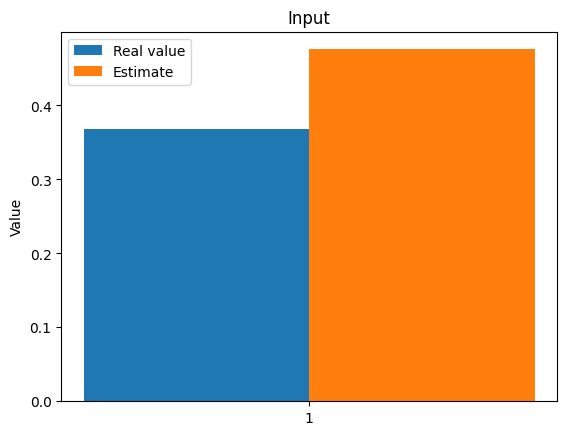

The function param_inverse took 894.1311221122742 seconds.
step random walk: 0.5
(1, 151, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_924916\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.16: 100%|██████████| 2000/2000 [07:31<00:00,  4.43it/s]


Sampling chain 2/2


Running chain, α = 0.31: 100%|██████████| 2000/2000 [07:08<00:00,  4.66it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.503]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.503  0.144    0.27    0.784      0.008    0.006     357.0     324.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.13457895]



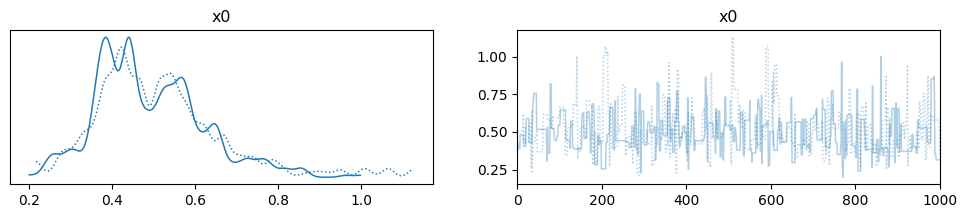

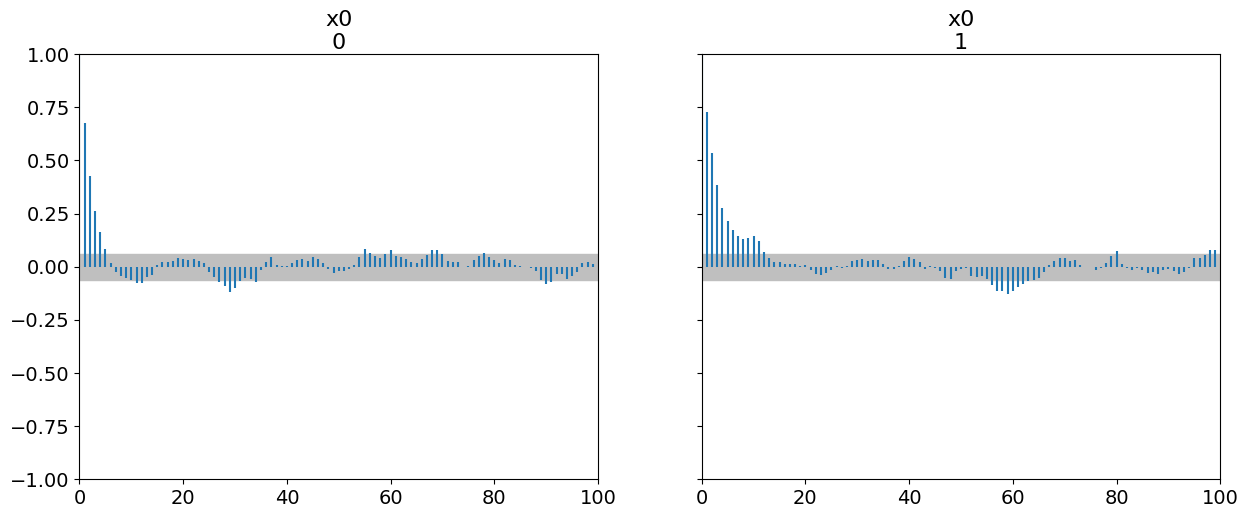

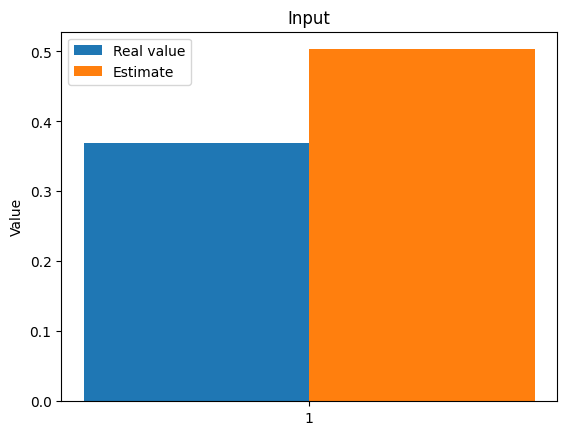

The function param_inverse took 881.8901886940002 seconds.
step random walk: 2.0
(1, 151, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_924916\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.20: 100%|██████████| 2000/2000 [07:10<00:00,  4.65it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 2000/2000 [07:07<00:00,  4.68it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.489]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.489  0.138   0.251    0.774      0.008    0.006     322.0     327.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.12057895]



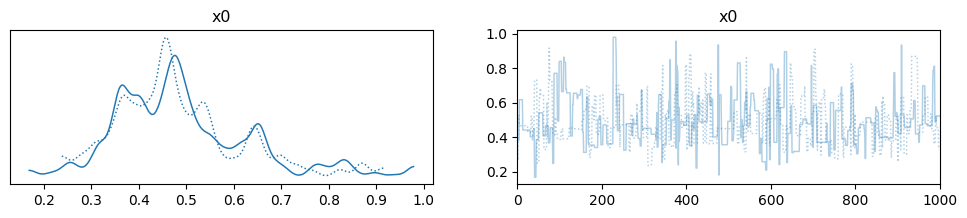

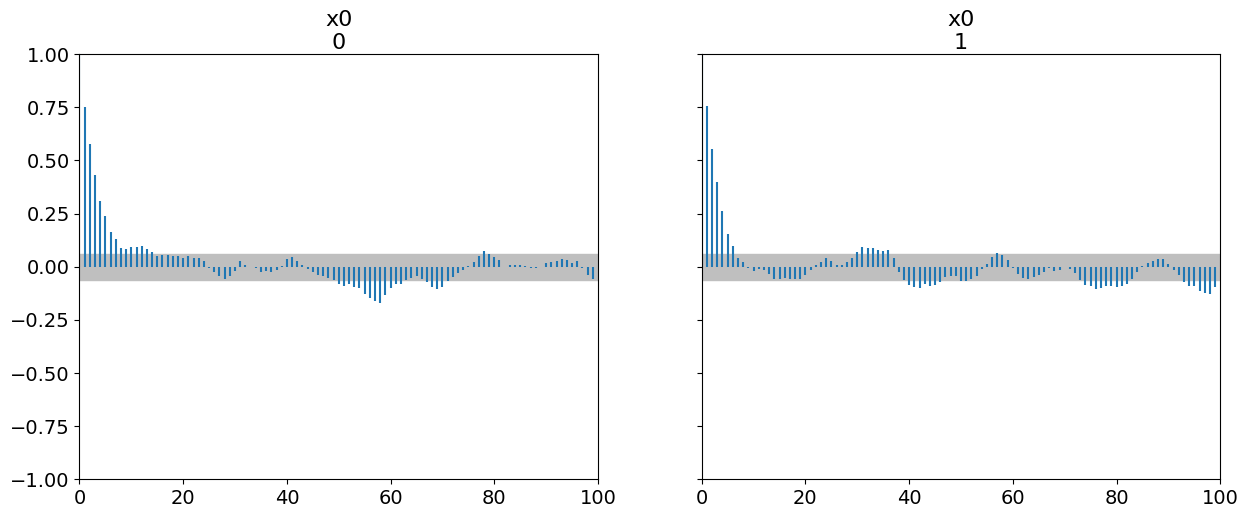

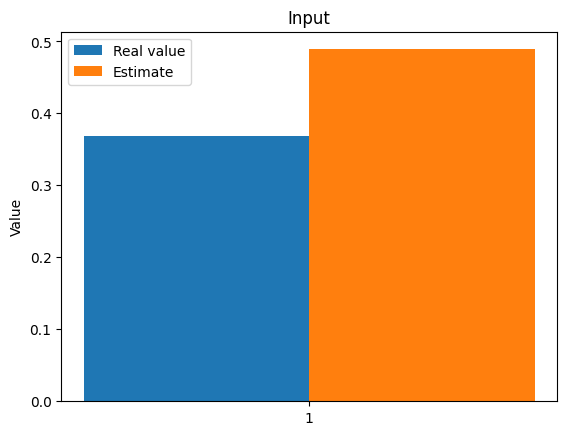

The function param_inverse took 858.9968733787537 seconds.
sigma: 4.0
step random walk: 0.1
(1, 151, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_924916\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.29:  59%|█████▉    | 1184/2000 [04:11<02:49,  4.82it/s]c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Burgers\../utils\Structure.py:998: RuntimeWarning: overflow encountered in exp
  return x/(t+1)/(1.0+np.exp(re*(x)/(4*t+4))*((t+1)/A0)**0.5)
Running chain, α = 0.24: 100%|██████████| 2000/2000 [07:05<00:00,  4.70it/s

Sampling chain 2/2


Running chain, α = 0.19: 100%|██████████| 2000/2000 [07:06<00:00,  4.69it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.756]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.756  0.482   -0.07    1.538       0.03    0.021     291.0     441.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.38757895]



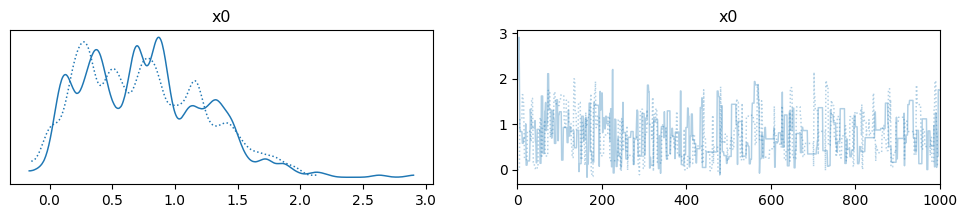

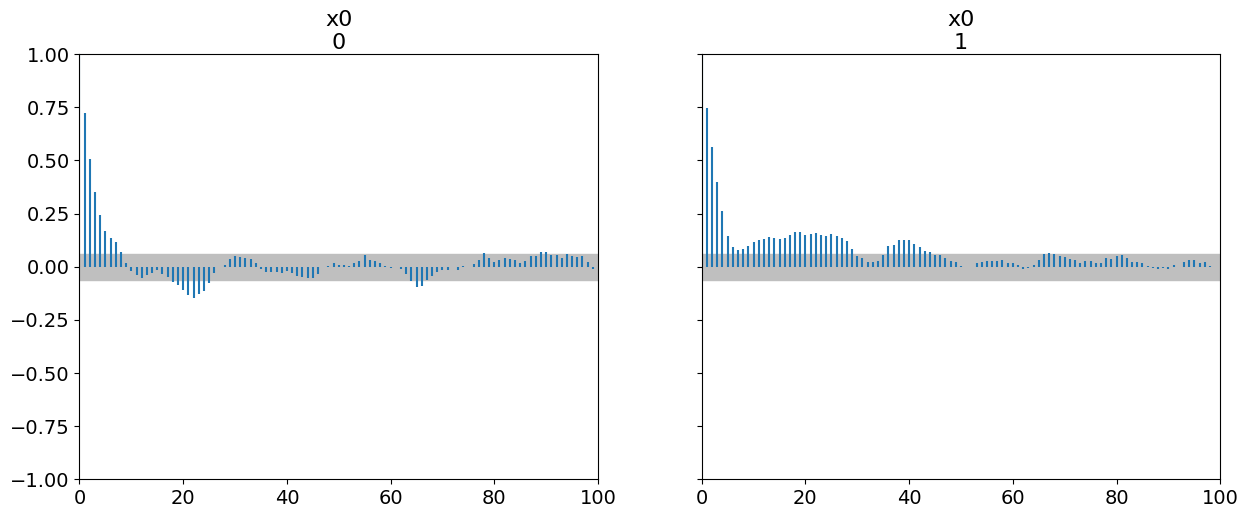

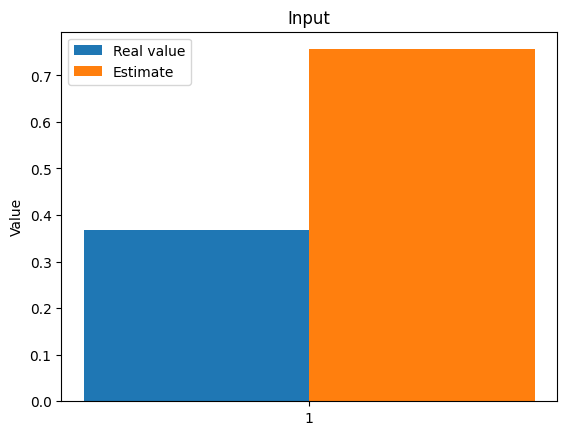

The function param_inverse took 853.3784477710724 seconds.
step random walk: 0.5
(1, 151, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_924916\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.36:  55%|█████▌    | 1101/2000 [03:53<03:06,  4.83it/s]c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Burgers\../utils\Structure.py:998: RuntimeWarning: overflow encountered in exp
  return x/(t+1)/(1.0+np.exp(re*(x)/(4*t+4))*((t+1)/A0)**0.5)
Running chain, α = 0.29: 100%|██████████| 2000/2000 [07:04<00:00,  4.71it/s

Sampling chain 2/2


Running chain, α = 0.26: 100%|██████████| 2000/2000 [07:09<00:00,  4.66it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.739]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.739  0.483  -0.083    1.561      0.027     0.02     331.0     190.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.37057895]



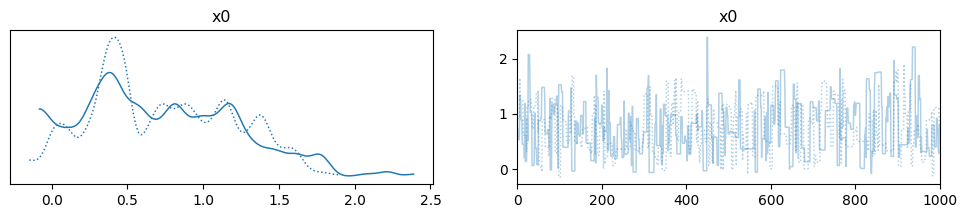

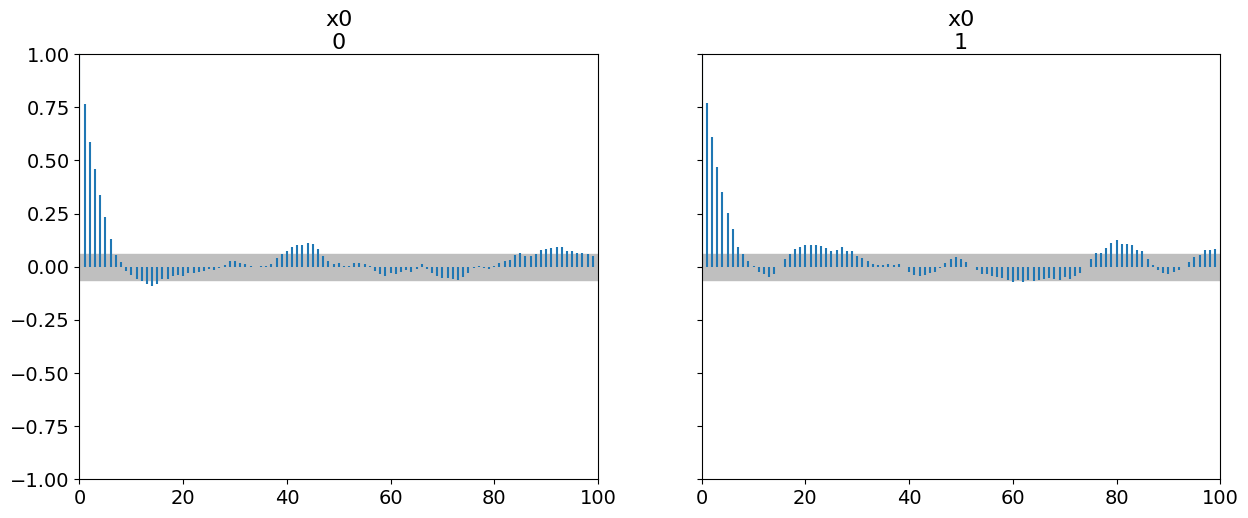

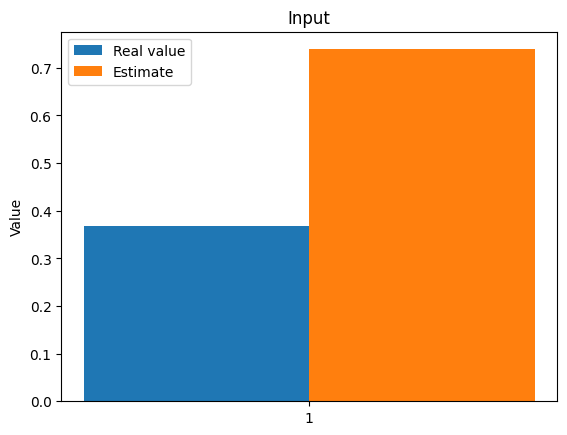

The function param_inverse took 855.4803450107574 seconds.
step random walk: 2.0
(1, 151, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_924916\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.24:   2%|▏         | 33/2000 [00:06<07:03,  4.64it/s]c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Burgers\../utils\Structure.py:998: RuntimeWarning: overflow encountered in exp
  return x/(t+1)/(1.0+np.exp(re*(x)/(4*t+4))*((t+1)/A0)**0.5)
Running chain, α = 0.28: 100%|██████████| 2000/2000 [07:08<00:00,  4.66it/s]


Sampling chain 2/2


Running chain, α = 0.27: 100%|██████████| 2000/2000 [07:24<00:00,  4.49it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.718]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.718  0.476  -0.063    1.535      0.028     0.02     320.0     338.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.34957895]



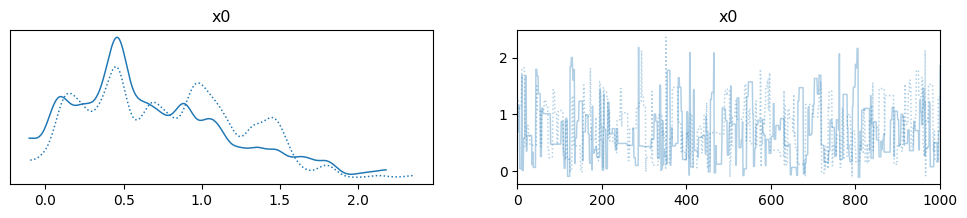

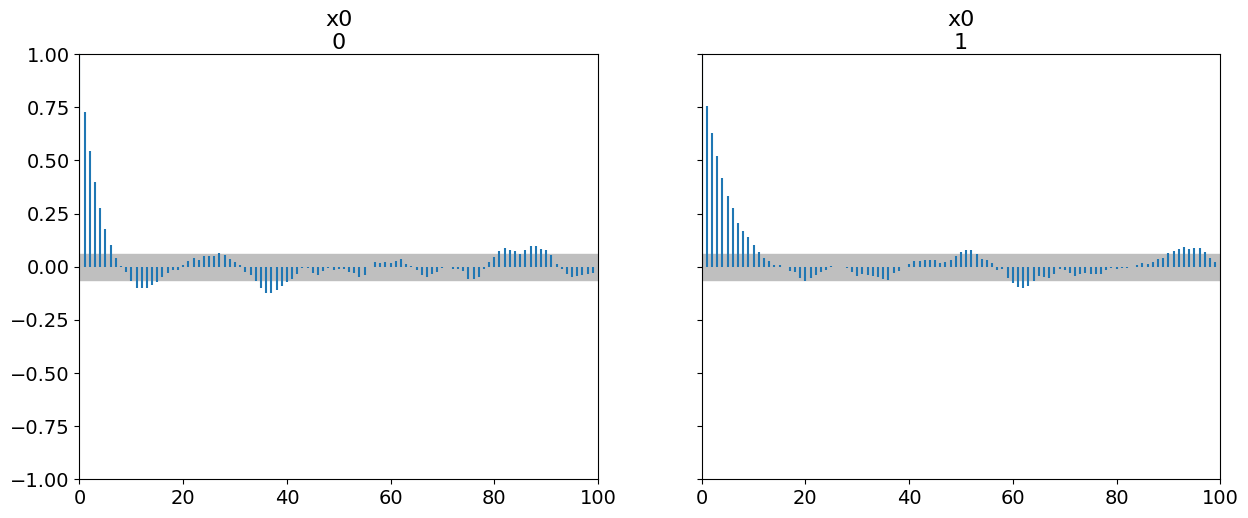

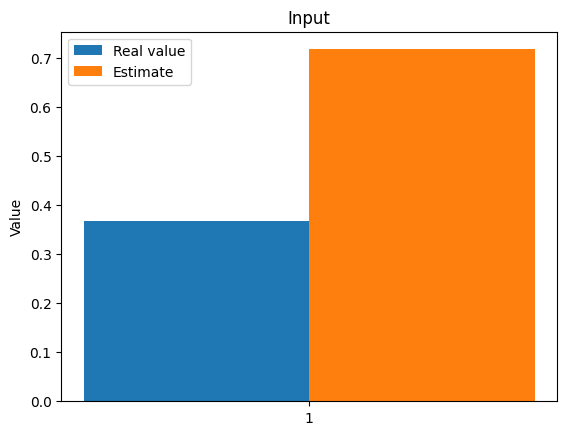

The function param_inverse took 875.1285281181335 seconds.
The best estimate is given by: sigma_noise=0.1, number of data= 151, sigma=0.5, rmwh_scaling=0.1
Noise: 0.1
Number of data: 151
sigma: 0.5
step random walk: 0.1
(1, 151, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_924916\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.36:   0%|          | 10/2000 [00:02<07:18,  4.54it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)

Sampling chain 2/2


Running chain, α = 0.25: 100%|██████████| 2000/2000 [07:27<00:00,  4.47it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.493]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.493  0.138   0.248    0.727      0.008    0.006     294.0     255.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.12457895]



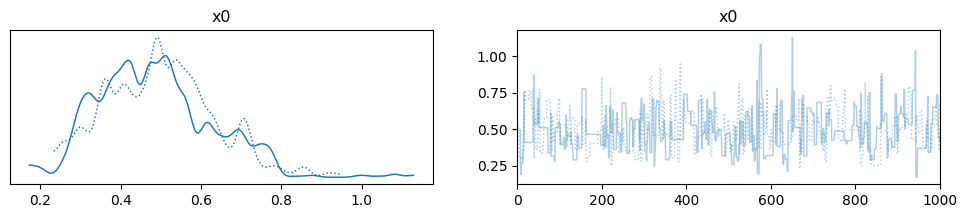

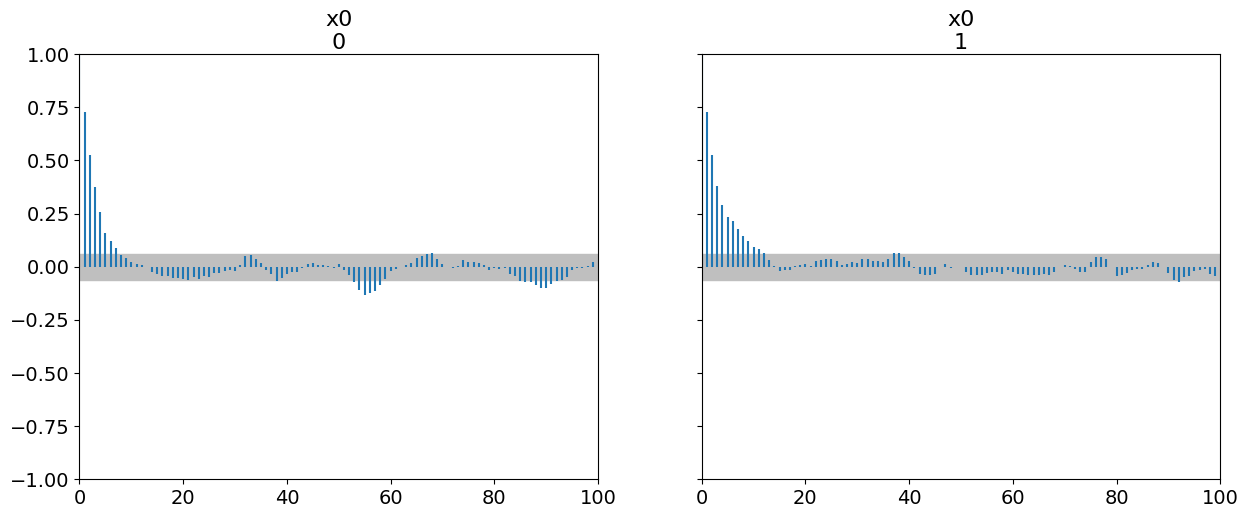

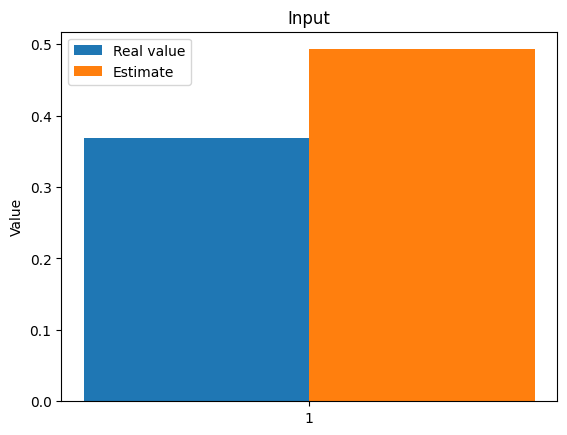

The function param_inverse took 893.214359998703 seconds.
step random walk: 0.5
(1, 151, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_924916\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.18: 100%|██████████| 2000/2000 [07:27<00:00,  4.47it/s]


Sampling chain 2/2


Running chain, α = 0.24: 100%|██████████| 2000/2000 [07:28<00:00,  4.45it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.518]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.518  0.146   0.278    0.803      0.008    0.006     335.0     379.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.14957895]



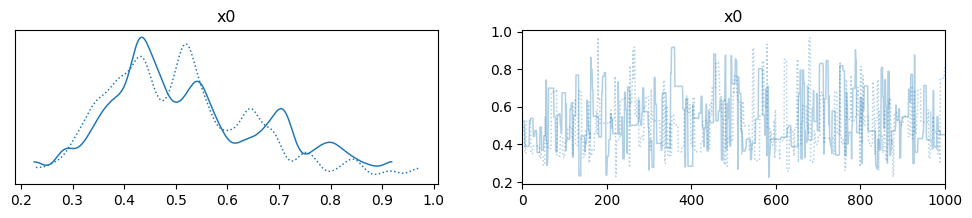

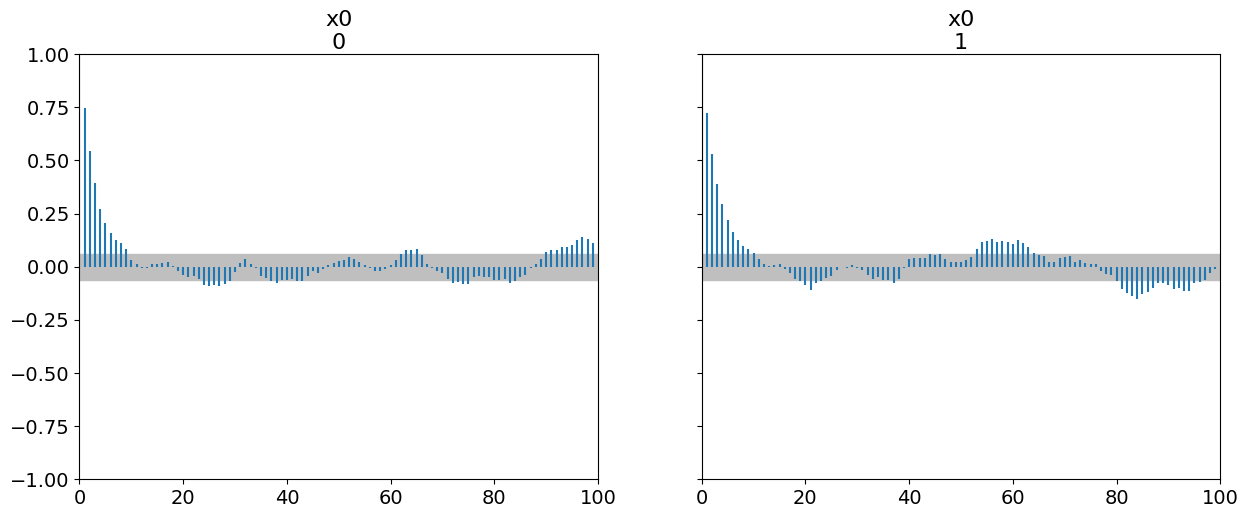

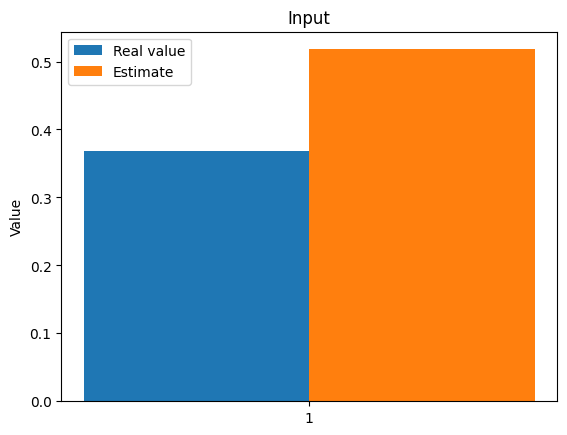

The function param_inverse took 898.0892052650452 seconds.
step random walk: 2.0
(1, 151, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_924916\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.24: 100%|██████████| 2000/2000 [07:12<00:00,  4.63it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 2000/2000 [07:19<00:00,  4.55it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.44]
    mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
x0  0.44  0.12   0.241    0.654      0.008    0.005     269.0     313.0   1.01
Autocorrelation...
the difference between estimated values [0.07157895]



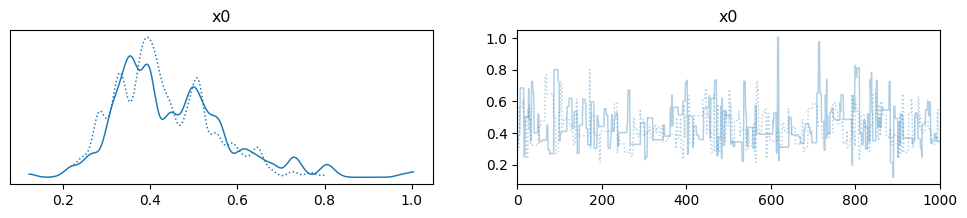

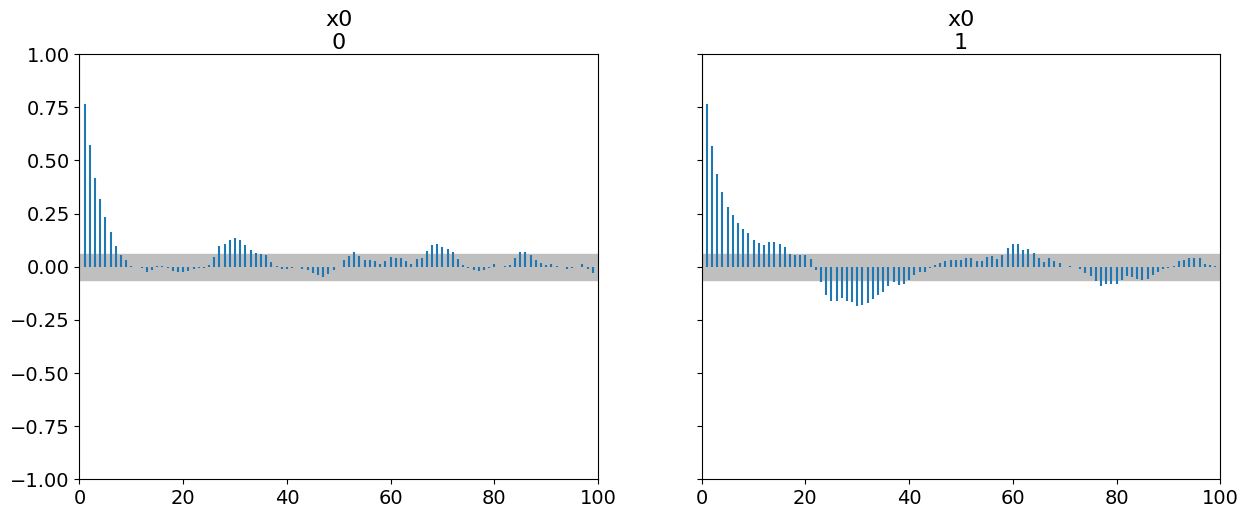

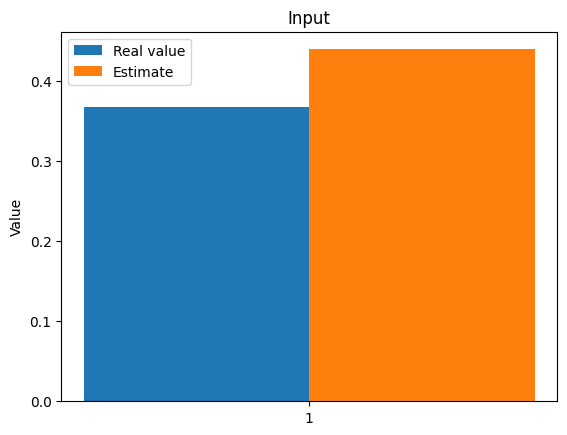

The function param_inverse took 873.965886592865 seconds.
sigma: 4.0
step random walk: 0.1
(1, 151, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_924916\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.29:  48%|████▊     | 965/2000 [03:37<03:53,  4.43it/s]


KeyboardInterrupt: 

In [15]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[151]
parameter=np.array([re_grid_lstm_test[0,0]])
indices = np.where(input_test[:,:,1] == parameter)[0]
mean_prior=np.array([.5])
cov_prior=np.diag([ .5])
# cov_linkelihood
sigma=np.array([.5,4.])   # NB, con sigma piccolo (e.g. 1) funzia, sigma troppo gaìrande no

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.1,0.5,2.])
rwmh_adaptive = True
iterations =2000
burnin = 1000
n_chains=2

algo="MH"


estimateMF, errorMF= run_simulation(basis,input_test, T,mean_prior, cov_prior, output_test, sigma_noise, n_data, parameter, sigma, rmwh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, model,algo)
# FUnziona, obiettivo ora, ridurre varianza della posterior

Noise: 0.05
Number of data: 110
sigma: 1.0
step random walk: 0.1
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/2


Running chain, α = 0.26: 100%|██████████| 2000/2000 [09:22<00:00,  3.55it/s]


Sampling chain 2/2


Running chain, α = 0.18: 100%|██████████| 2000/2000 [09:22<00:00,  3.56it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.186]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.186  0.061   0.066    0.273      0.004    0.003     263.0     279.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.18242105]



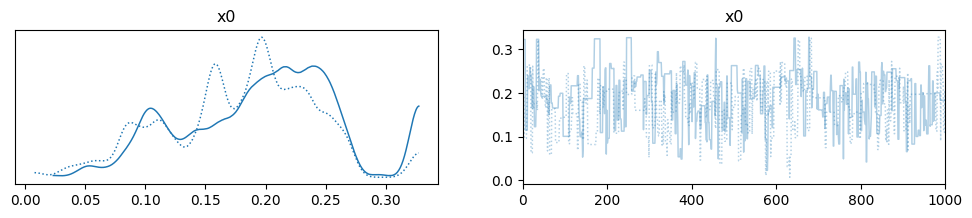

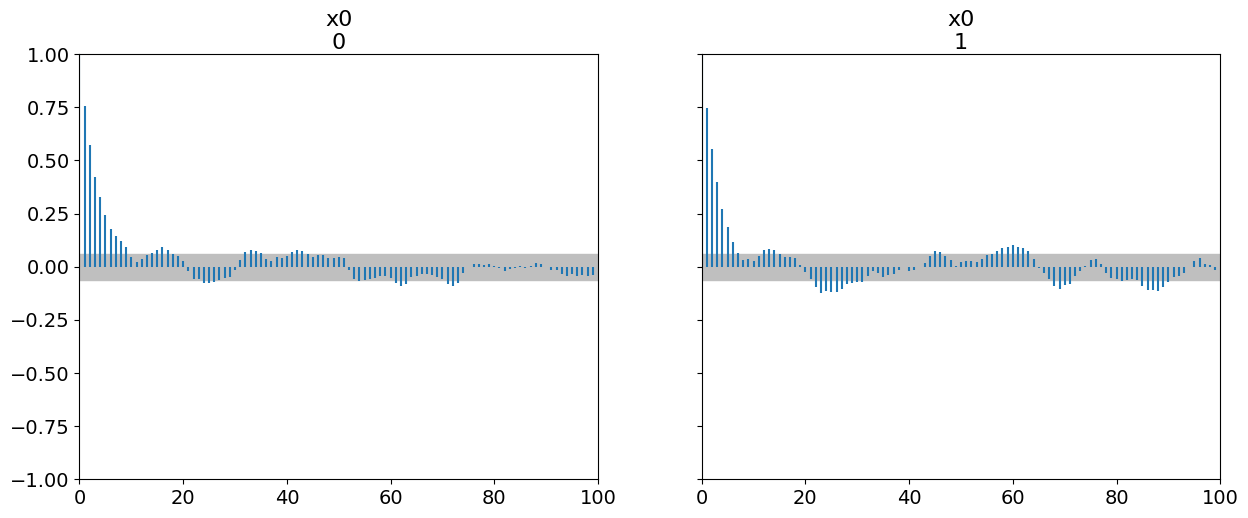

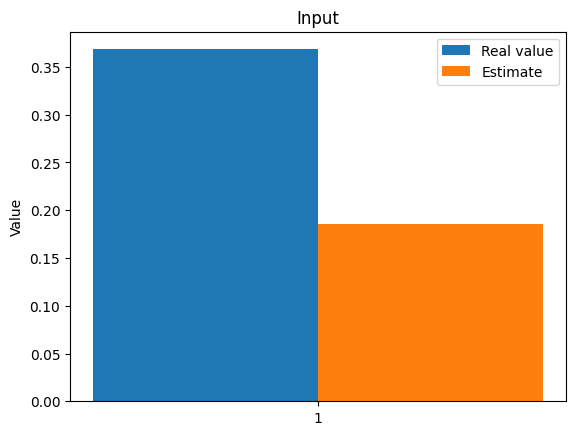

The function param_inverse took 1126.8373420238495 seconds.
step random walk: 0.2
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13904\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.25: 100%|██████████| 2000/2000 [09:15<00:00,  3.60it/s]


Sampling chain 2/2


Running chain, α = 0.13: 100%|██████████| 2000/2000 [09:08<00:00,  3.65it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.196]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.196  0.059   0.071    0.272      0.004    0.003     215.0     334.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.17242105]



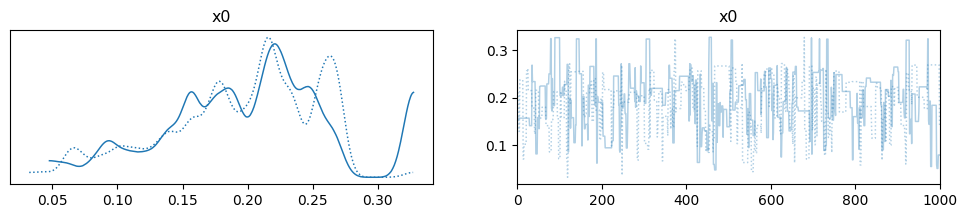

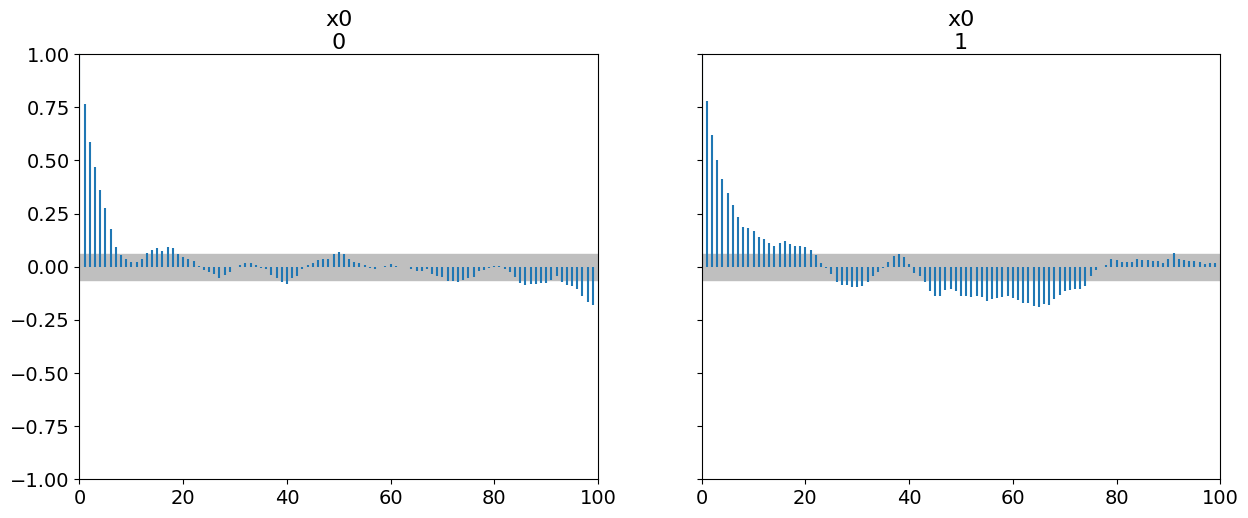

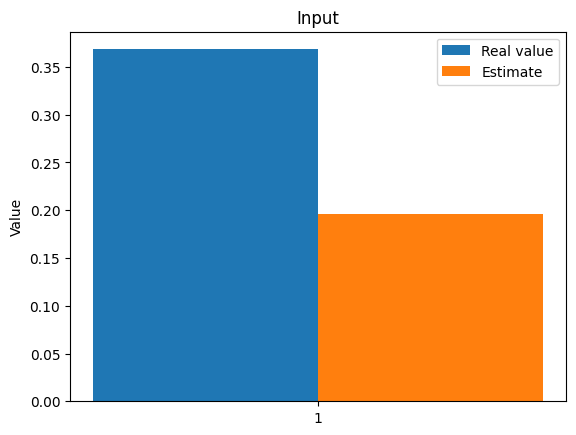

The function param_inverse took 1105.7467200756073 seconds.
step random walk: 0.05
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13904\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.23: 100%|██████████| 2000/2000 [09:14<00:00,  3.61it/s]


Sampling chain 2/2


Running chain, α = 0.29: 100%|██████████| 2000/2000 [09:13<00:00,  3.61it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.321]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.321  0.277   0.055    0.933       0.17    0.136       4.0      25.0   

    r_hat  
x0   1.42  
Autocorrelation...
the difference between estimated values [0.04742105]



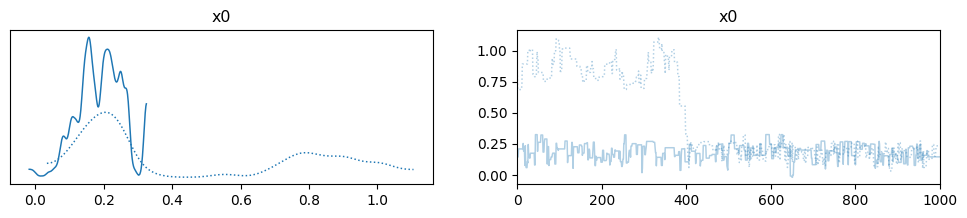

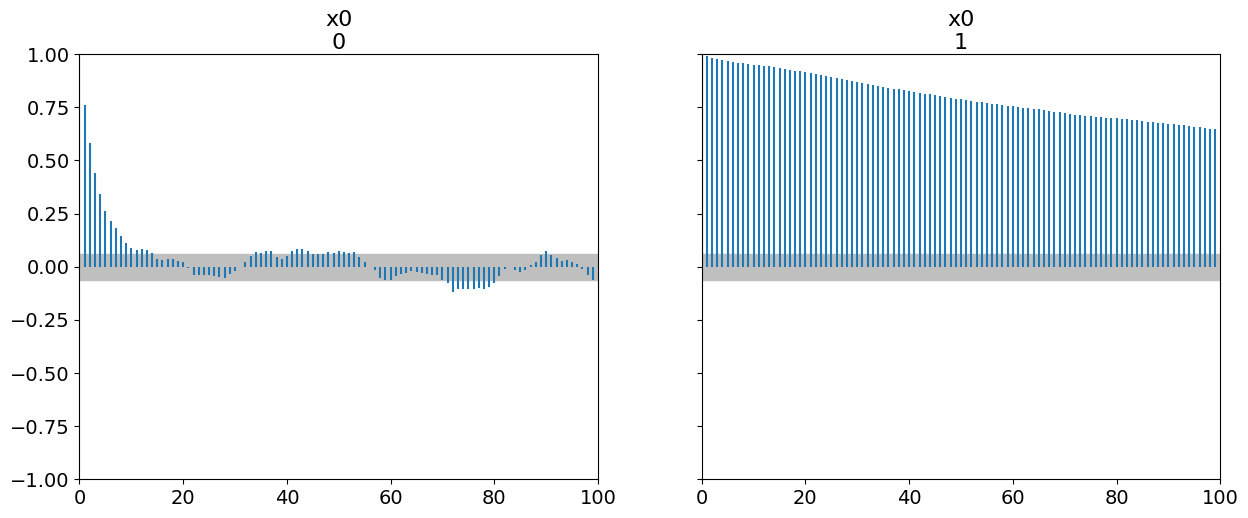

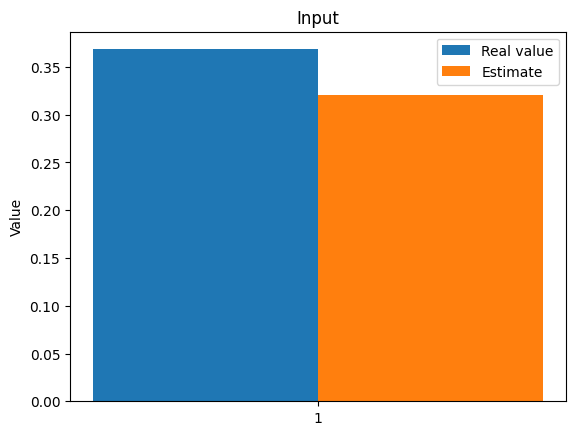

The function param_inverse took 1110.0197749137878 seconds.
sigma: 2.0
step random walk: 0.1
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13904\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.09: 100%|██████████| 2000/2000 [09:18<00:00,  3.58it/s]


Sampling chain 2/2


Running chain, α = 0.26: 100%|██████████| 2000/2000 [09:17<00:00,  3.59it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-0.368]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -0.368  0.931  -1.266    1.252      0.613    0.505       3.0      38.0   

    r_hat  
x0   1.85  
Autocorrelation...
the difference between estimated values [0.73642105]



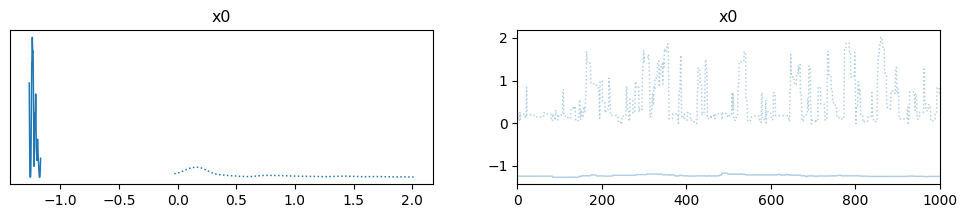

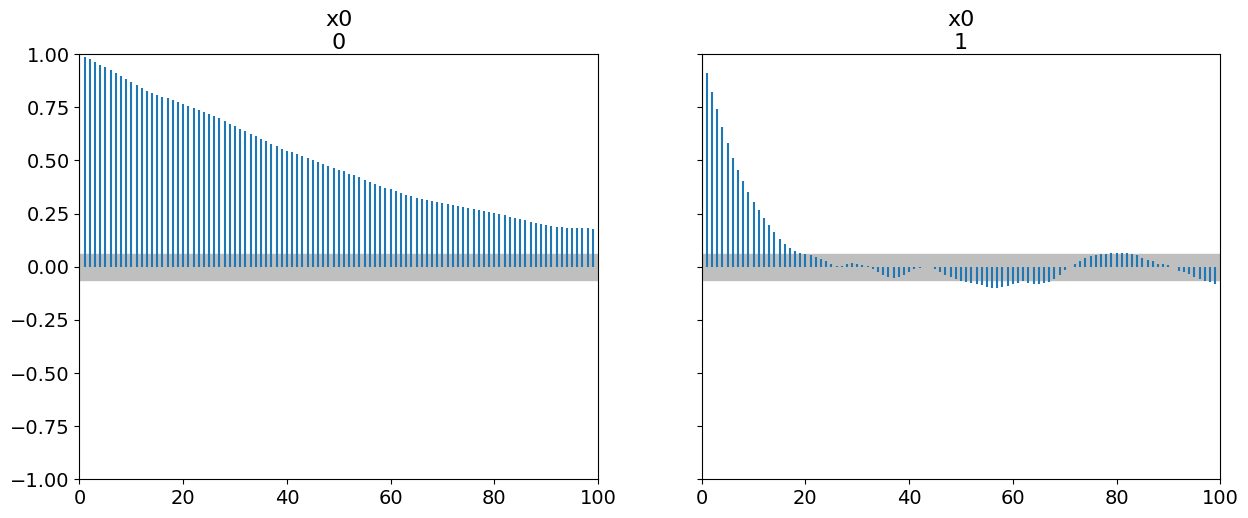

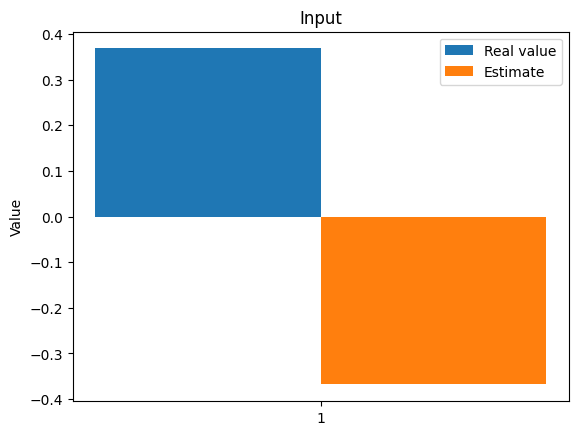

The function param_inverse took 1117.4563705921173 seconds.
step random walk: 0.2
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13904\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.25:   1%|          | 23/2000 [00:07<10:13,  3.22it/s]


KeyboardInterrupt: 

In [20]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[110]
parameter=np.array([re_grid_lstm_test[0,0]])
#indices = np.where(input_test[:,:,1] == parameter)[0]
mean_prior=np.array([.5])
cov_prior=np.diag([1])
# cov_linkelihood
sigma=np.array([1,2,4.])   # NB, con sigma piccolo (e.g. 1) funzia, sigma troppo gaìrande no

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.1,0.2,0.05])
rwmh_adaptive = True
iterations =2000
burnin = 1000
n_chains=2

algo="MH"


estimateMF, errorMF= run_simulation(basis,input_test, T,mean_prior, cov_prior, output_test, sigma_noise, n_data, parameter, sigma, rmwh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, model,algo)
# FUnziona, obiettivo ora, ridurre varianza della posterior

In [27]:
re_grid_lstm_test[2,0]

0.7894736842105263

Noise: 0.05
Number of data: 70
sigma: 0.1
step random walk: 0.2
(1, 70, 18)
real values are [0.78947368]
Sampling chain 1/3


Running chain, α = 0.22: 100%|██████████| 3000/3000 [06:42<00:00,  7.46it/s]


Sampling chain 2/3


Running chain, α = 0.24: 100%|██████████| 3000/3000 [06:38<00:00,  7.54it/s]


Sampling chain 3/3


Running chain, α = 0.19: 100%|██████████| 3000/3000 [06:27<00:00,  7.74it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.915]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.915  0.145   0.653    1.195      0.006    0.005     533.0     366.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.12552632]



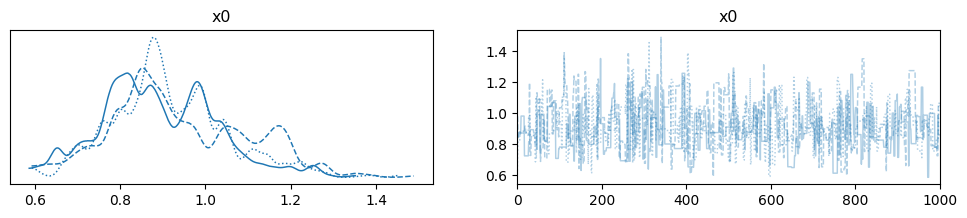

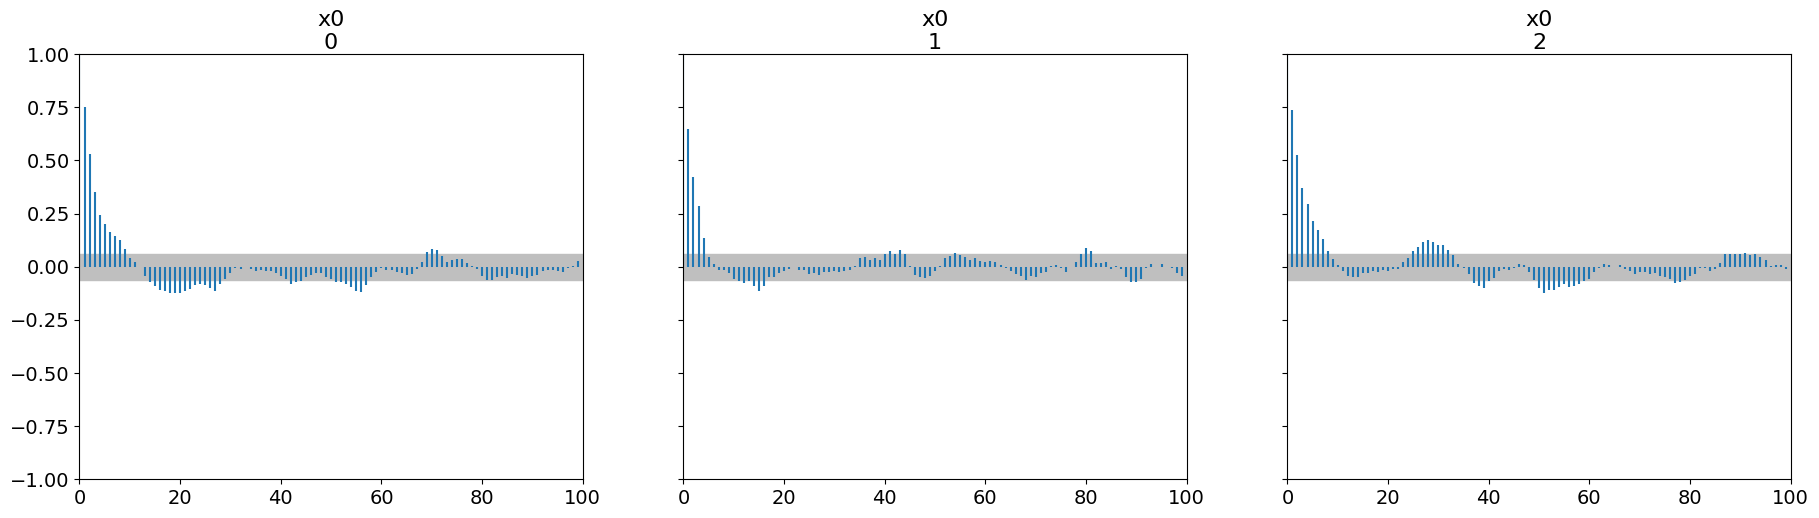

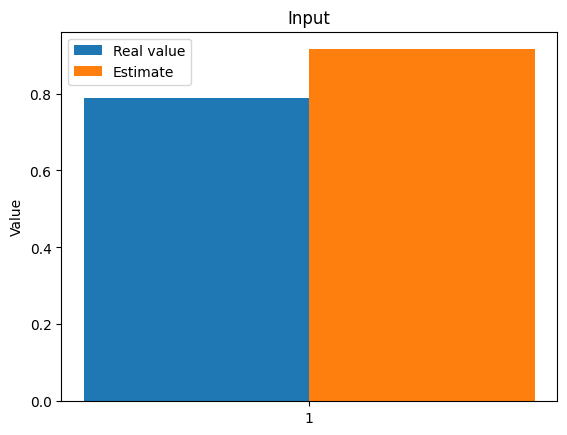

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_901768\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)


The function param_inverse took 1188.80401968956 seconds.
sigma: 0.3
step random walk: 0.2
(1, 70, 18)
real values are [0.78947368]
Sampling chain 1/3


Running chain, α = 0.17: 100%|██████████| 3000/3000 [06:27<00:00,  7.73it/s]


Sampling chain 2/3


Running chain, α = 0.19: 100%|██████████| 3000/3000 [06:30<00:00,  7.69it/s]


Sampling chain 3/3


Running chain, α = 0.32: 100%|██████████| 3000/3000 [06:31<00:00,  7.67it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.027]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.027  0.345   0.464     1.64      0.017    0.012     416.0     316.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.23752632]



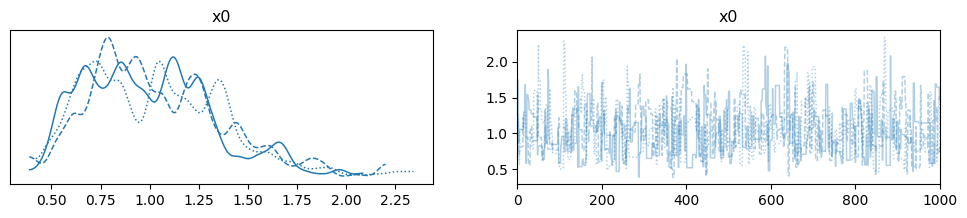

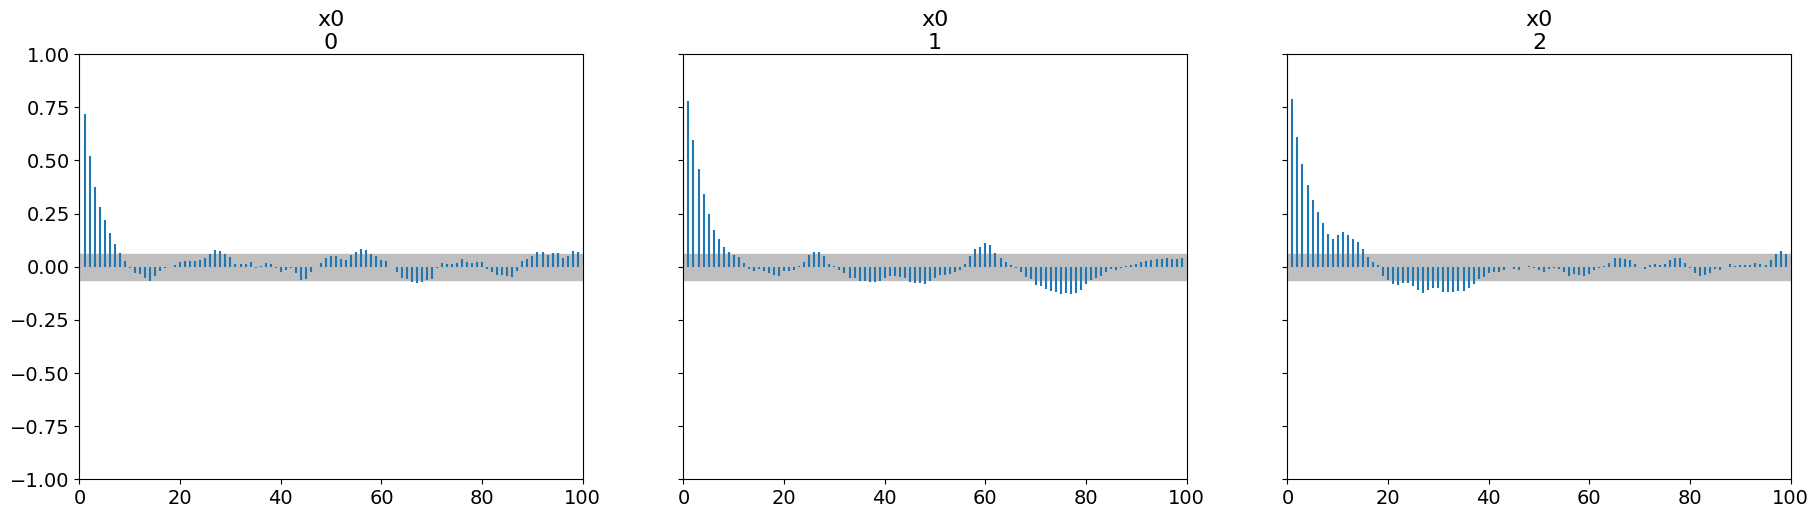

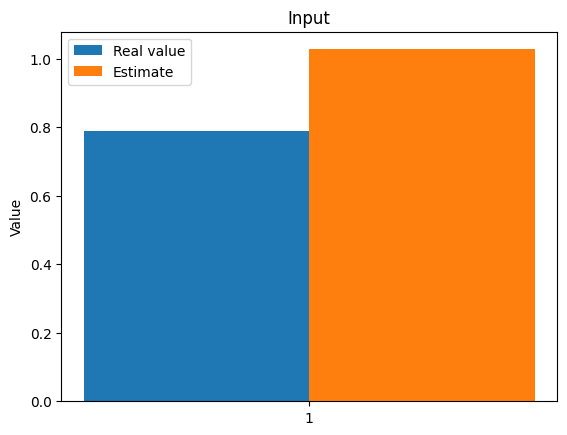

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_901768\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)


The function param_inverse took 1170.5323848724365 seconds.
sigma: 0.5
step random walk: 0.2
(1, 70, 18)
real values are [0.78947368]
Sampling chain 1/3


Running chain, α = 0.19:  50%|████▉     | 1490/3000 [03:13<03:08,  8.02it/s]c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Burgers\../utils\Structure.py:1002: RuntimeWarning: overflow encountered in exp
  return x/(t+1)/(1.0+np.exp(re*(x)/(4*t+4))*((t+1)/A0)**0.5)
Running chain, α = 0.12: 100%|██████████| 3000/3000 [06:30<00:00,  7.68it/s]


Sampling chain 2/3


Running chain, α = 0.68:   8%|▊         | 225/3000 [00:31<06:23,  7.23it/s]


KeyboardInterrupt: 

In [16]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[70]
parameter=np.array([re_grid_lstm_test[2,0]])
#indices = np.where(input_test[:,:,1] == parameter)[0]
mean_prior=np.array([.5])
cov_prior=np.diag([.5])
# cov_linkelihood
sigma=np.array([0.1,0.3,0.5,1,2,4.])   # NB, con sigma piccolo (e.g. 1) funzia, sigma troppo gaìrande no

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.2])    # 0.05 sembra problema sia esplorazione
rwmh_adaptive = True
iterations =3000
burnin = 2000
n_chains=3

algo="MH"


estimateMF, errorMF= run_simulation(basis,input_test, T,mean_prior, cov_prior, output_test, sigma_noise, n_data, parameter, sigma, rmwh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, model,algo)
# FUnziona, obiettivo ora, ridurre varianza della posterior

Noise: 0.05
Number of data: 110
sigma: 0.1
step random walk: 0.5
(1, 110, 18)
real values are [0.78947368]
Sampling chain 1/2


Running chain, α = 0.29: 100%|██████████| 3000/3000 [09:49<00:00,  5.09it/s]


Sampling chain 2/2


Running chain, α = 0.25: 100%|██████████| 3000/3000 [09:40<00:00,  5.17it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.963]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.963  0.103   0.758    1.138      0.006    0.004     353.0     426.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.17352632]



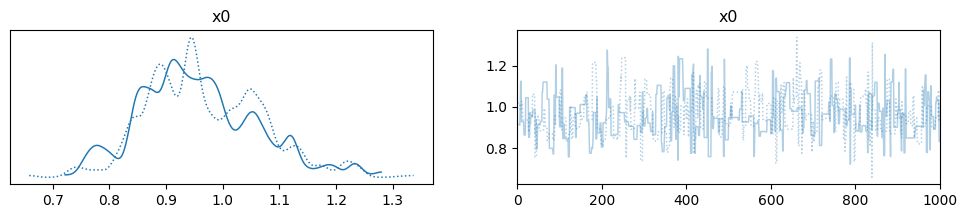

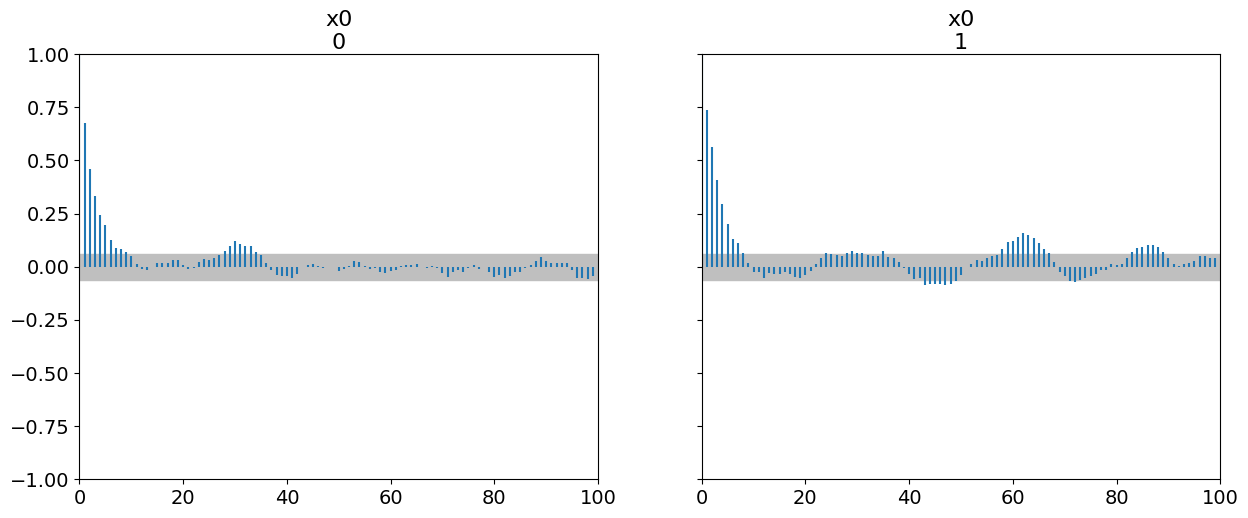

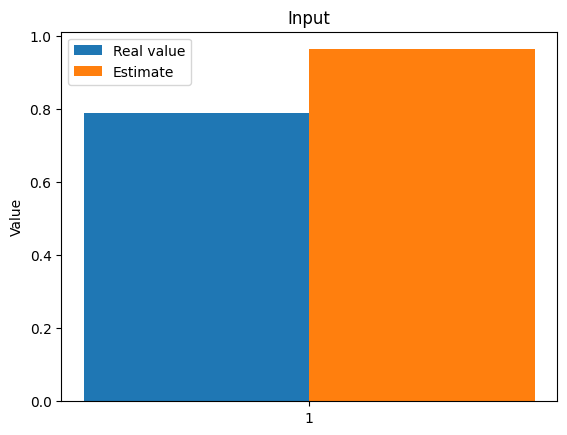

The function param_inverse took 1171.2950723171234 seconds.
step random walk: 0.2
(1, 110, 18)
real values are [0.78947368]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_56072\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.37:   2%|▏         | 74/3000 [00:14<09:44,  5.00it/s]


KeyboardInterrupt: 

In [22]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[110]
parameter=np.array([re_grid_lstm_test[2,0]])
#indices = np.where(input_test[:,:,1] == parameter)[0]
mean_prior=np.array([.5])
cov_prior=np.diag([.5])
# cov_linkelihood
sigma=np.array([0.1,0.3,0.5,1,2,4.])   # NB, con sigma piccolo (e.g. 1) funzia, sigma troppo gaìrande no

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,0.2])    # 0.05 sembra problema sia esplorazione
rwmh_adaptive = True
iterations =3000
burnin = 2000
n_chains=2

algo="MH"


estimateMF, errorMF= run_simulation(basis,input_test, T,mean_prior, cov_prior, output_test, sigma_noise, n_data, parameter, sigma, rmwh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, model,algo)
# FUnziona, obiettivo ora, ridurre varianza della posterior

Noise: 0.05
Number of data: 110
sigma: 0.1
step random walk: 0.5
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/2


Running chain, α = 0.50:   0%|          | 1/3000 [00:00<07:23,  6.76it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.28: 100%|██████████| 3000/3000 [10:49<00:00,  4.62it/s]


Sampling chain 2/2


Running chain, α = 0.20: 100%|██████████| 3000/3000 [11:12<00:00,  4.46it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.361]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.361  0.026   0.319    0.408      0.002    0.001     301.0     277.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.00742105]



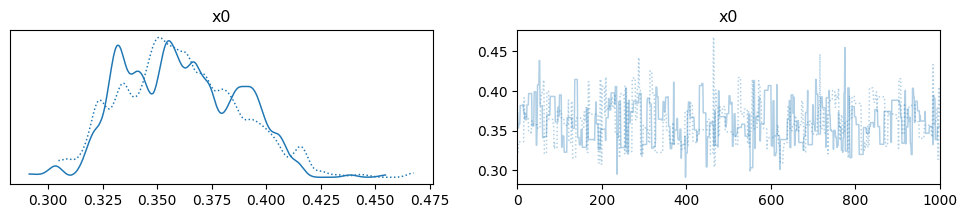

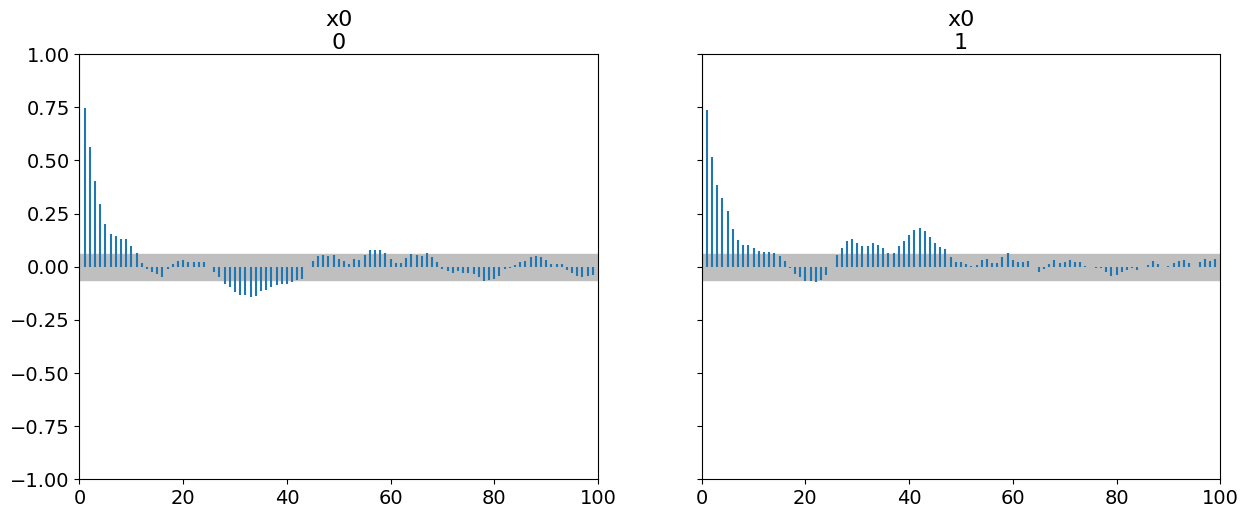

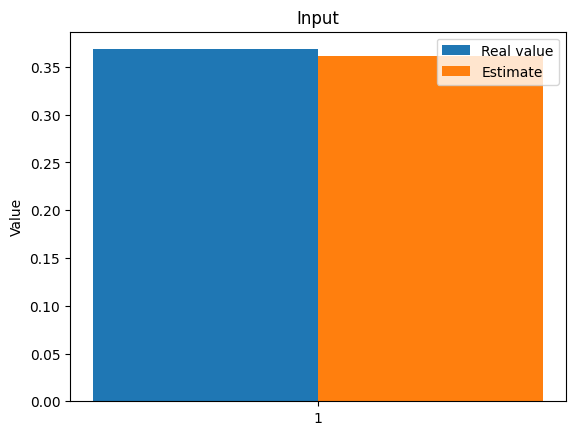

The function param_inverse took 1323.2723925113678 seconds.
step random walk: 0.2
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_56072\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.33:   0%|          | 2/3000 [00:00<09:09,  5.45it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
R

KeyboardInterrupt: 

In [21]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[110]
parameter=np.array([re_grid_lstm_test[0,0]])
#indices = np.where(input_test[:,:,1] == parameter)[0]
mean_prior=np.array([.5])
cov_prior=np.diag([.5])
# cov_linkelihood
sigma=np.array([0.1,0.3,0.5,1,2,4.])   # NB, con sigma piccolo (e.g. 1) funzia, sigma troppo gaìrande no

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,0.2])    # 0.05 sembra problema sia esplorazione
rwmh_adaptive = True
iterations =3000
burnin = 2000
n_chains=2

algo="MH"


estimateMF, errorMF= run_simulation(basis,input_test, T,mean_prior, cov_prior, output_test, sigma_noise, n_data, parameter, sigma, rmwh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, model,algo)
# FUnziona, obiettivo ora, ridurre varianza della posterior

Noise: 0.05
Number of data: 110
sigma: 0.3
step random walk: 0.5
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/2


Running chain, α = 1.00:   0%|          | 0/3000 [00:00<?, ?it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.26: 100%|██████████| 3000/3000 [08:54<00:00,  5.62it/s]


Sampling chain 2/2


Running chain, α = 0.19: 100%|██████████| 3000/3000 [14:19<00:00,  3.49it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.413]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.413  0.104   0.265    0.605      0.006    0.004     320.0     360.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.04457895]



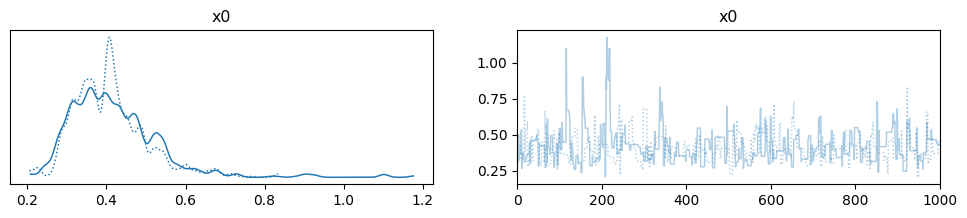

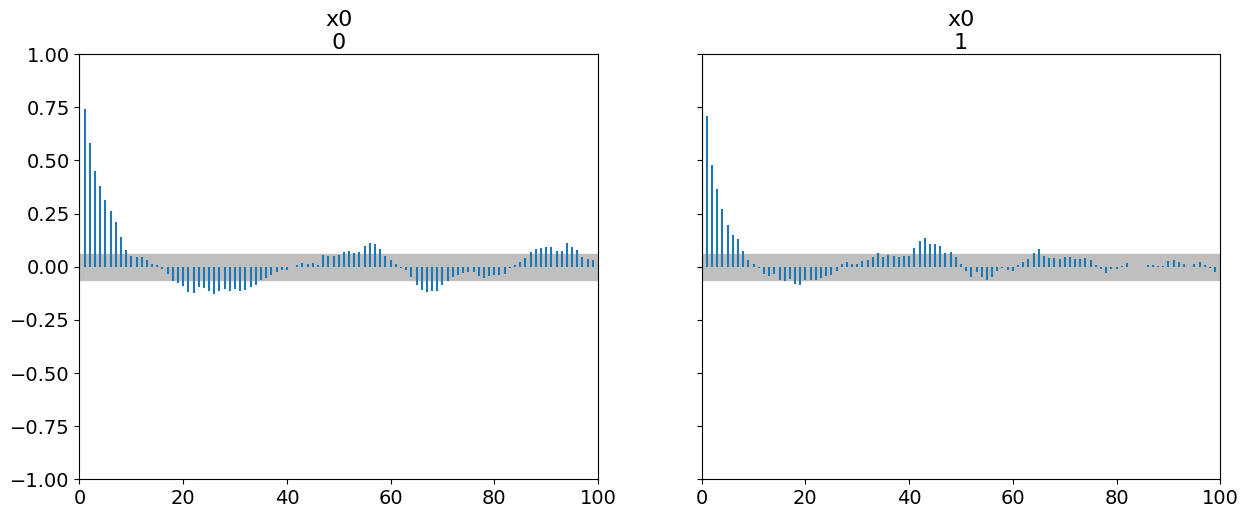

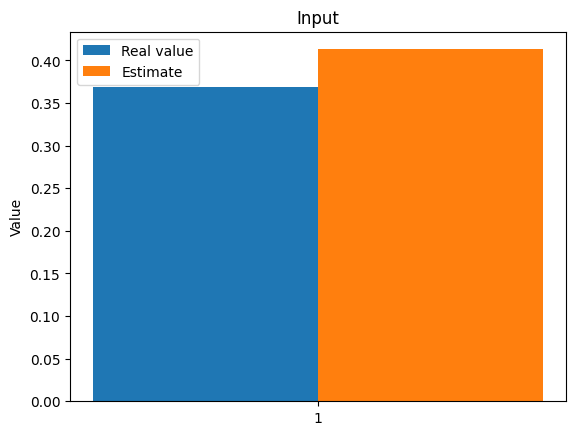

The function param_inverse took 1394.3833403587341 seconds.
step random walk: 0.2
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/2


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_56072\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
Running chain, α = 0.17: 100%|██████████| 3000/3000 [09:20<00:00,  5.35it/s]


Sampling chain 2/2


Running chain, α = 0.29: 100%|██████████| 3000/3000 [12:57<00:00,  3.86it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.436]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.436  0.096   0.281    0.611      0.007    0.005     180.0     252.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.06757895]



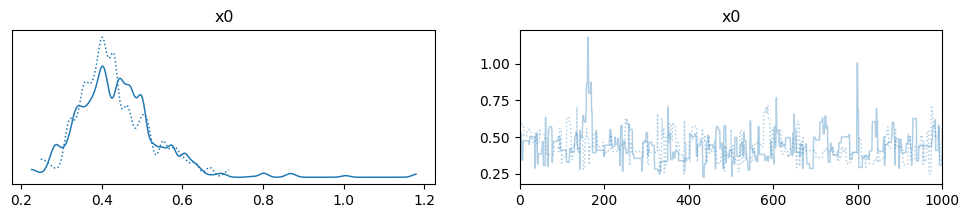

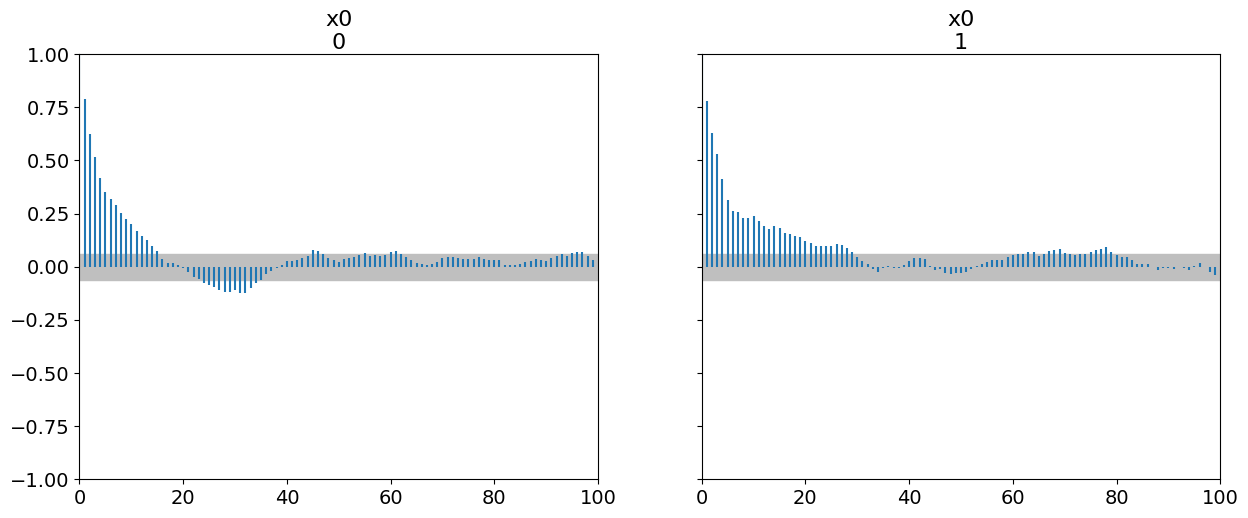

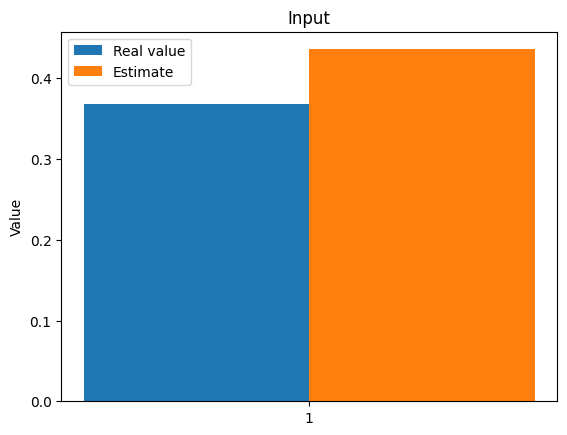

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_56072\3456175106.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)


The function param_inverse took 1339.11505651474 seconds.
sigma: 0.5
step random walk: 0.5
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/2


Running chain, α = 0.41:   2%|▏         | 67/3000 [00:13<09:30,  5.14it/s]


KeyboardInterrupt: 

In [19]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[110]
parameter=np.array([re_grid_lstm_test[0,0]])
#indices = np.where(input_test[:,:,1] == parameter)[0]
mean_prior=np.array([.5])
cov_prior=np.diag([.5])
# cov_linkelihood
sigma=np.array([0.3,0.5,1,2,4.])   # NB, con sigma piccolo (e.g. 1) funzia, sigma troppo gaìrande no

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,0.2])    # 0.05 sembra problema sia esplorazione
rwmh_adaptive = True
iterations =3000
burnin = 2000
n_chains=2

algo="MH"


estimateMF, errorMF= run_simulation(basis,input_test, T,mean_prior, cov_prior, output_test, sigma_noise, n_data, parameter, sigma, rmwh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, model,algo)
# FUnziona, obiettivo ora, ridurre varianza della posterior

In [17]:
basis.shape

(101, 16)

In [16]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[110]
parameter=np.array([re_grid_lstm_test[0,0]])
#indices = np.where(input_test[:,:,1] == parameter)[0]
mean_prior=np.array([.5])
cov_prior=np.diag([1])
# cov_linkelihood
sigma=np.array([1,2,4.])   # NB, con sigma piccolo (e.g. 1) funzia, sigma troppo gaìrande no

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.1,0.2,0.05])
rwmh_adaptive = True
iterations =3000
burnin = 1500
n_chains=3

algo="MH"


estimateMF, errorMF= run_simulation(basis,input_test, T,mean_prior, cov_prior, output_test, sigma_noise, n_data, parameter, sigma, rmwh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, model,algo)
# FUnziona, obiettivo ora, ridurre varianza della posterior

Noise: 0.05
Number of data: 110
sigma: 1.0
step random walk: 0.1
(1, 110, 18)
real values are [0.36842105]
Sampling chain 1/3


Running chain, α = 0.46:  17%|█▋        | 512/3000 [01:30<07:19,  5.66it/s]


KeyboardInterrupt: 

In [ ]:
    @compute_time
    def param_inverse(self, mean_prior, x_data, cov_prior=None, cov_noise=0.1, cov_likelihood=None, y_obs=None, x_real=None, number_chains=1, N=1000, burn_in=500, levels=1,diagnostic=True,rwmh_cov=None,rmwh_scaling=0.1,rwmh_adaptive=True, algo="MH",transformation=[]):
            # I should insert the 
        self.transformations=transformation
        self.inputs=x_data

        # rivedere la questione dimensioni (x_real!=y_obs)
        if x_real is not None:
            dim = x_real.shape[0]
        elif y_obs is not None:
            dim=y_obs.shape[0]
        else: 
            warning_message = "No observation nor data given"
            warnings.warn(warning_message, UserWarning)    

        if (N<=burn_in):
            warning_message = "number of steps insufficient, smaller or equal than burn-in"
            warnings.warn(warning_message, UserWarning) 

        if(cov_prior is None):
            cov_prior=mean_prior*0.2

        if(cov_likelihood is None):
            cov_likelihood=cov_noise**2*np.eye(x_real.shape[0])

0.7894736842105263